# §0 整體實驗設計

本作業以 `SEED = 411278018` 固定所有隨機程序，在 AT&T 40 Faces 與 Yale Face B 兩個人臉資料集上，交叉評估三類 shallow classifiers——Multinomial Logistic Regression（MLR）、Support Vector Machine（SVM）與 Artificial Neural Network（ANN）——分別搭配 raw pixels 與 PCA-reduced features，構成 $2 \times 3 \times 2 = 12$ 個實驗單元。資料切分採 stratified 80/20，以確保每個身分類別在 train/test 中維持相近比例；超參數選擇透過 cross-validation 完成，主指標為 test accuracy，輔以 macro F1 衡量類別平均表現，並記錄 fit 與 predict 的 median time（3 runs）作為效率比較依據。

兩個資料集的成像條件構成本實驗的核心對照。AT&T 40 Faces 在受控燈光與固定背景下拍攝，類內變異主要來自人臉幾何與表情；Yale Face B 以多角度極端光源刻意放大類內光照變異，使同一人在不同打光下的像素距離可能遠大於不同人之間的差距。此根本差異決定了 PCA 壓縮所保留的資訊類型、分類器能否建立穩定決策邊界，以及超參數搜尋空間是否充分——後續 12 個實驗單元間的多數差異均可回溯至此。

| cell | dataset | classifier | feature |
|---:|---|---|---|
| 1 | AT&T 40 Faces | MLR | Raw pixels |
| 2 | AT&T 40 Faces | MLR | PCA-reduced |
| 3 | AT&T 40 Faces | SVM | Raw pixels |
| 4 | AT&T 40 Faces | SVM | PCA-reduced |
| 5 | AT&T 40 Faces | ANN | Raw pixels |
| 6 | AT&T 40 Faces | ANN | PCA-reduced |
| 7 | Yale Face B | MLR | Raw pixels |
| 8 | Yale Face B | MLR | PCA-reduced |
| 9 | Yale Face B | SVM | Raw pixels |
| 10 | Yale Face B | SVM | PCA-reduced |
| 11 | Yale Face B | ANN | Raw pixels |
| 12 | Yale Face B | ANN | PCA-reduced |

所有 `StandardScaler` 與 PCA 封裝於 `sklearn.pipeline.Pipeline` 內，`fit` 僅作用於 training fold，再 transform validation 與 test data。此設計旨在防止 PCA 或 scaling 在 full data 上預先接觸 test distribution——即便洩漏效果微小，其後果為直接污染分類結果，而非形式上的程式設計問題。

In [5]:
from __future__ import annotations

import json
import os
import tempfile
import time
import warnings
from collections import Counter
from pathlib import Path
from typing import Any

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.io import loadmat
from skimage.transform import resize
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.base import clone
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from joblib import parallel_backend
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="The number of unique classes is greater than 50%.*")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive.*")
warnings.filterwarnings("ignore", message="More than 20 figures have been opened.*")

SEED = 411278018
rng = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "InClassCoding").exists() else NOTEBOOK_DIR.parent
DATA_DIR = ROOT / "InClassCoding" / "data"
OUTPUT_DIR = ROOT / "Homework"

ATTNT_PATH = DATA_DIR / "face_data.csv"
YALE_PATH = DATA_DIR / "allFaces.mat"
MASTER_RESULTS_PATH = OUTPUT_DIR / "master_results.csv"

CV_FOLDS = 5
ANN_CV_FOLDS = 3
TIMING_RUNS = 3
TAB10 = plt.get_cmap("tab10")

results: list[dict[str, Any]] = []
best_estimators: dict[tuple[str, str, str], Pipeline] = {}
best_params_by_key: dict[tuple[str, str, str], dict[str, Any]] = {}
predictions_by_key: dict[tuple[str, str, str], np.ndarray] = {}

print(f"ROOT = {ROOT}")
print(f"numpy={np.__version__}, pandas={pd.__version__}, scipy={scipy.__version__}, sklearn={sklearn.__version__}")


ROOT = /Users/moses/Dev/Moses/academic/courses/Programming/Shallow_Machine_Learning/ml_course
numpy=2.2.6, pandas=2.3.3, scipy=1.15.3, sklearn=1.7.2


# §1 資料載入與前處理模組

本實驗使用兩個人臉資料來源：AT&T 40 Faces 取自 `InClassCoding/data/face_data.csv`，Yale Face B 取自 `InClassCoding/data/allFaces.mat`。AT&T 影像已展平為 $64 \times 64$ 灰階影像對應的 4,096 維向量；Yale 原始影像為 $192 \times 168$，且 `.mat` 檔案以 column-major 順序儲存，還原時須指定 `order='F'`，再以 anti-aliasing resize 至 $64 \times 64$ 後展平。此下採樣步驟統一兩個資料集的輸入維度為 4,096，使 raw pixel 與 PCA 兩條特徵路徑在計算成本上具可比性。

AT&T 像素值為 $[0,255]$ 整數，先除以 255 映射至 $[0,1]$，再由 `StandardScaler` 執行 z-score 標準化，以消除原始像素尺度對 MLR 梯度更新與 ANN Adam 優化器初期步長的數值干擾。Yale Face B 原始展平維度為 $192 \times 168 = 32{,}256$；若以此維度直接進入 grid search，PCA 分解、SVM 核矩陣與 ANN 前向傳遞均將承受不成比例的計算負擔，因此統一下採樣至 $64 \times 64$，使分類任務在 4,096 維空間中進行。`anti_aliasing=True` 在下採樣前施加低通濾波，保留對人臉辨識具有判別力的低頻輪廓與光照結構，而非追求像素級重建精度。

資料切分採 stratified 80/20，以隔離類別組成對評估指標的干擾：若特定類別在 test set 中樣本過少，accuracy 與 macro F1 均會受類別分布而非模型能力所驅動，進而使 12 個實驗單元間的比較失去可比性。

AT&T: X=(400, 4096), y=(400,), classes=40, min=0.0000, max=1.0000, mean=0.5470
AT&T class distribution: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10, np.int64(3): 10, np.int64(4): 10, np.int64(5): 10, np.int64(6): 10, np.int64(7): 10, np.int64(8): 10, np.int64(9): 10, np.int64(10): 10, np.int64(11): 10, np.int64(12): 10, np.int64(13): 10, np.int64(14): 10, np.int64(15): 10, np.int64(16): 10, np.int64(17): 10, np.int64(18): 10, np.int64(19): 10, np.int64(20): 10, np.int64(21): 10, np.int64(22): 10, np.int64(23): 10, np.int64(24): 10, np.int64(25): 10, np.int64(26): 10, np.int64(27): 10, np.int64(28): 10, np.int64(29): 10, np.int64(30): 10, np.int64(31): 10, np.int64(32): 10, np.int64(33): 10, np.int64(34): 10, np.int64(35): 10, np.int64(36): 10, np.int64(37): 10, np.int64(38): 10, np.int64(39): 10}


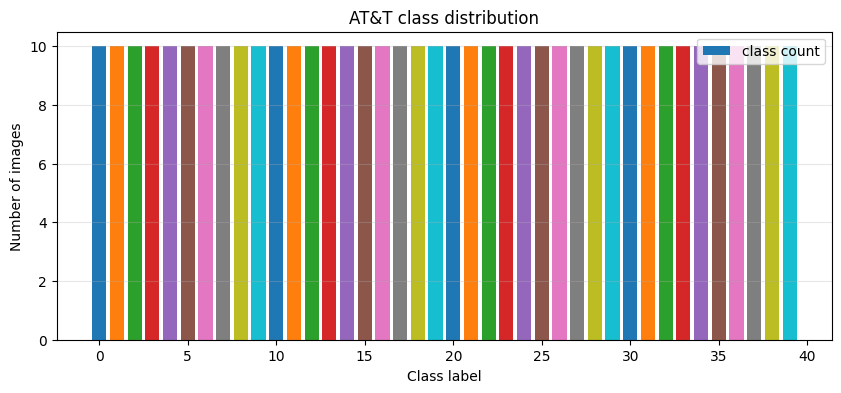

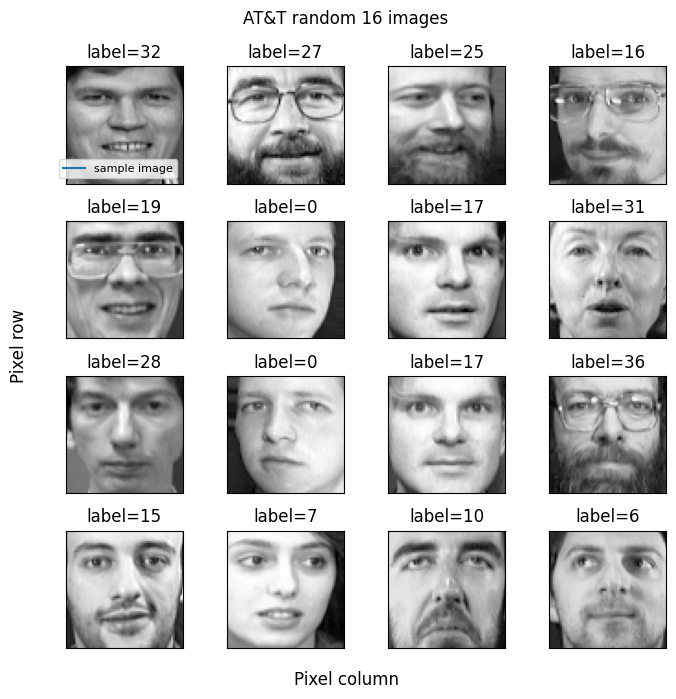

Yale: X=(2410, 4096), y=(2410,), classes=38, min=0.0000, max=1.0000, mean=0.2726
Yale class distribution: {np.int64(0): 64, np.int64(1): 62, np.int64(2): 64, np.int64(3): 64, np.int64(4): 62, np.int64(5): 64, np.int64(6): 64, np.int64(7): 64, np.int64(8): 64, np.int64(9): 64, np.int64(10): 60, np.int64(11): 59, np.int64(12): 60, np.int64(13): 63, np.int64(14): 62, np.int64(15): 63, np.int64(16): 63, np.int64(17): 64, np.int64(18): 64, np.int64(19): 64, np.int64(20): 64, np.int64(21): 64, np.int64(22): 64, np.int64(23): 64, np.int64(24): 64, np.int64(25): 64, np.int64(26): 64, np.int64(27): 64, np.int64(28): 64, np.int64(29): 64, np.int64(30): 64, np.int64(31): 64, np.int64(32): 64, np.int64(33): 64, np.int64(34): 64, np.int64(35): 64, np.int64(36): 64, np.int64(37): 64}


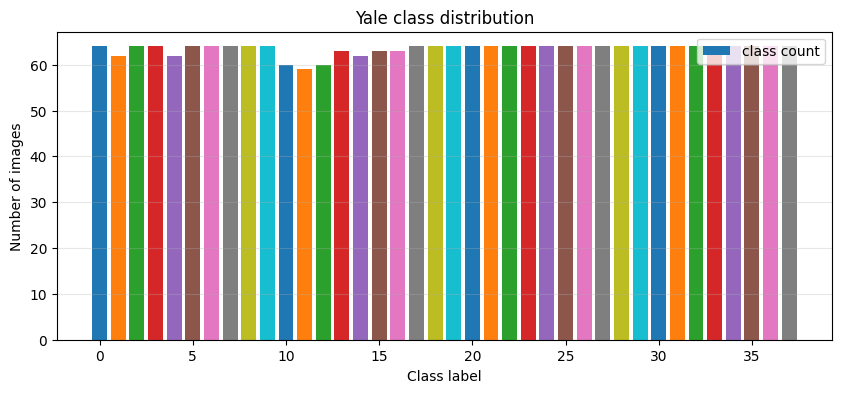

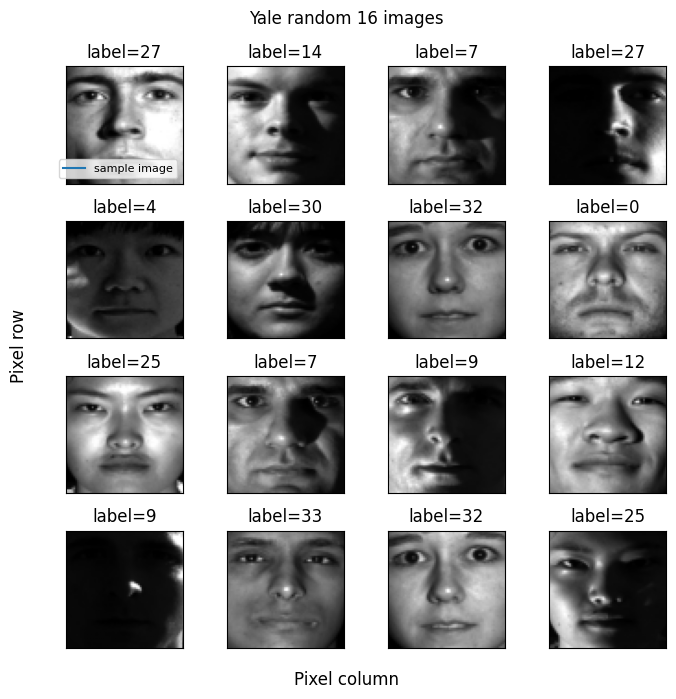

numpy=2.2.6, sklearn=1.7.2


In [6]:
def load_attnt(path: Path) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(path)
    if "target" not in df.columns:
        raise ValueError("AT&T CSV must include a target column.")
    X = df.drop(columns=["target"]).to_numpy(dtype=np.float64)
    y = df["target"].to_numpy(dtype=np.int64)
    if X.max() > 1.0:
        X = X / 255.0
    return X, y


def load_yale(path: Path, target_size: tuple[int, int] = (64, 64)) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(path)
    faces = mat["faces"]
    nfaces = mat["nfaces"].ravel().astype(int)
    X_rows: list[np.ndarray] = []
    y_rows: list[int] = []

    start = 0
    for label, count in enumerate(nfaces):
        for col_idx in range(start, start + count):
            image = np.reshape(faces[:, col_idx], (192, 168), order="F")
            small = resize(
                image,
                target_size,
                anti_aliasing=True,
                preserve_range=False,
            )
            X_rows.append(small.astype(np.float64).reshape(-1))
            y_rows.append(label)
        start += count

    return np.vstack(X_rows), np.asarray(y_rows, dtype=np.int64)


def load_yale_original_images(path: Path) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(path)
    faces = mat["faces"]
    nfaces = mat["nfaces"].ravel().astype(int)
    images: list[np.ndarray] = []
    labels: list[int] = []

    start = 0
    for label, count in enumerate(nfaces):
        for col_idx in range(start, start + count):
            image = np.reshape(faces[:, col_idx], (192, 168), order="F").astype(np.float64) / 255.0
            images.append(image)
            labels.append(label)
        start += count
    return np.asarray(images), np.asarray(labels, dtype=np.int64)


def make_split(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = 0.2,
    seed: int = SEED,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    counts = Counter(y)
    if min(counts.values()) < 2:
        raise ValueError("Stratified split requires at least two samples per class.")
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )


def plot_class_distribution(y: np.ndarray, dataset_name: str) -> None:
    counts = Counter(y)
    labels = sorted(counts)
    values = [counts[label] for label in labels]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, values, color=[TAB10(i % 10) for i in labels], label="class count")
    ax.set_title(f"{dataset_name} class distribution")
    ax.set_xlabel("Class label")
    ax.set_ylabel("Number of images")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()


def plot_sample_grid(X: np.ndarray, y: np.ndarray, dataset_name: str, image_shape: tuple[int, int] = (64, 64)) -> None:
    indices = rng.choice(np.arange(len(y)), size=16, replace=False)
    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for ax, idx in zip(axes.ravel(), indices, strict=True):
        ax.imshow(X[idx].reshape(image_shape), cmap="gray")
        ax.set_title(f"label={y[idx]}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.15)
    axes.ravel()[0].plot([], [], color=TAB10(0), label="sample image")
    axes.ravel()[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{dataset_name} random 16 images")
    fig.supxlabel("Pixel column")
    fig.supylabel("Pixel row")
    plt.tight_layout()
    plt.show()


X_attnt, y_attnt = load_attnt(ATTNT_PATH)
X_yale, y_yale = load_yale(YALE_PATH)

splits = {
    "AT&T": make_split(X_attnt, y_attnt),
    "Yale": make_split(X_yale, y_yale),
}

datasets = {
    "AT&T": {"X": X_attnt, "y": y_attnt, "shape": (64, 64), "split": splits["AT&T"]},
    "Yale": {"X": X_yale, "y": y_yale, "shape": (64, 64), "split": splits["Yale"]},
}

for name, data in datasets.items():
    X, y = data["X"], data["y"]
    print(
        f"{name}: X={X.shape}, y={y.shape}, classes={len(np.unique(y))}, "
        f"min={X.min():.4f}, max={X.max():.4f}, mean={X.mean():.4f}"
    )
    print(f"{name} class distribution: {dict(sorted(Counter(y).items()))}")
    plot_class_distribution(y, name)
    plot_sample_grid(X, y, name)

print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


# §2 PCA 特徵工程模組

Karhunen--Loève theorem 保證 PCA 是在所有 $k$ 維正交投影中最大化保留樣本變異的解。給定資料矩陣 $X \in \mathbb{R}^{n \times p}$，中心化資料為

$$
\tilde{X} = X - \mathbf{1}\bar{x}^\top .
$$

樣本共變異矩陣為

$$
S = \frac{1}{n-1}\tilde{X}^\top\tilde{X}.
$$

若

$$
S v_i = \lambda_i v_i,\quad \lambda_1 \ge \lambda_2 \ge \cdots,
$$

且 $V_k=[v_1,\dots,v_k]$，$v_i$ 由 $Sv_i=\lambda_i v_i$ 決定至正負號（sign），
MyPCA 與 sklearn 的比較以 $|\cdot|$ 消除符號不確定性，故 component\_abs\_diff=0。則投影為

$$
Z = \tilde{X} V_k.
$$

PCA 所選的 $V_k$ 滿足

$$
\arg\max_{V^\top V=I_k} \mathrm{tr}(V^\top S V) = V_k,
$$

即在所有 $k$ 維正交子空間中使樣本變異最大。重建式為

$$
\hat{X} = Z V_k^\top + \mathbf{1}\bar{x}^\top,
$$

其 Frobenius reconstruction error 為

$$
\lVert X-\hat X\rVert_F^2 = (n-1)\sum_{i>k}\lambda_i.
$$

當 `n_components` 為浮點數門檻時，`MyPCA` 以累積解釋變異量選取最小可行維度：`searchsorted` 以 `side='right'` 回傳使累積解釋變異量嚴格超過指定門檻的最小 $k$；當累積和恰好等於門檻時，`side='right'` 多取一個成分，以確保浮點精度邊界下門檻不被低估。

在分類器前引入 PCA 的目的在於提供正交且低冗餘的特徵座標，而非單純降低維度。Raw pixels 的 4,096 個欄位高度共線：對 MLR 而言，梯度在相鄰像素間反覆分配，收斂方向不穩定；對 RBF SVM 而言，每次距離計算涉及 $p=4{,}096$ 維特徵，在 cross-validation grid search 下時間成本迅速成為主要瓶頸。PCA 將主要影像變異集中至少數正交成分，使後續 kernel 距離計算與 ANN 結構搜尋在可接受時間內完成。

以 95% 累積解釋變異量為門檻，AT&T 對應 $k_{95}=111$，Yale 對應 $k_{95}=50$。Yale 所需成分更少，與其類內變異主要由光照方向與陰影梯度主導一致。此結果在後續分析中具有直接含義：高累積解釋變異量不等同於高分類辨識力——當前幾個主成分主要描述 illumination 而非 identity 時，PCA 壓縮反而可能保留對分類無益的方向。

`MyPCA` 採 `np.linalg.svd` 直接分解中心化資料矩陣，而非顯式建立 $S \in \mathbb{R}^{p \times p}$ 後再進行特徵分解。當 $p \gg n$ 時，此作法在取得奇異值與右奇異向量的同時，避免高維共變異矩陣的顯式建構，數值穩定性更佳。

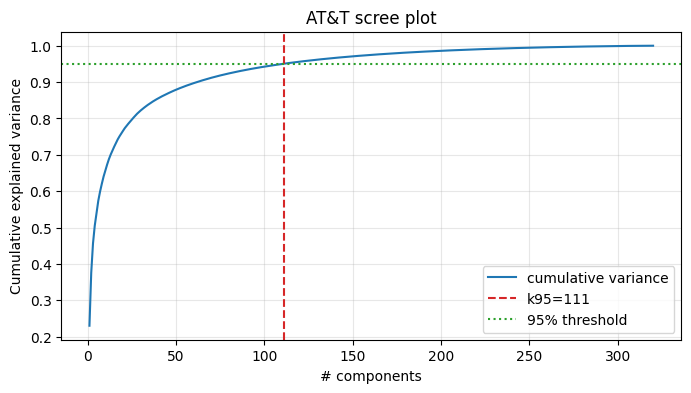

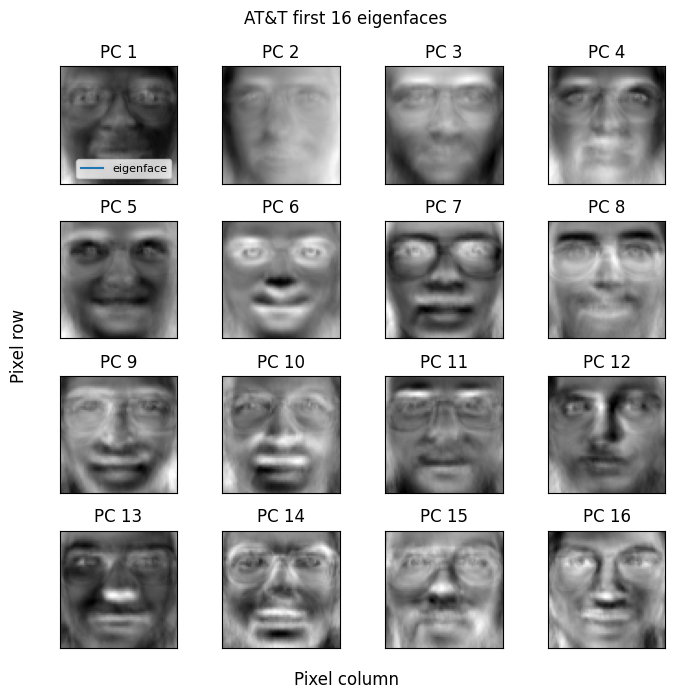

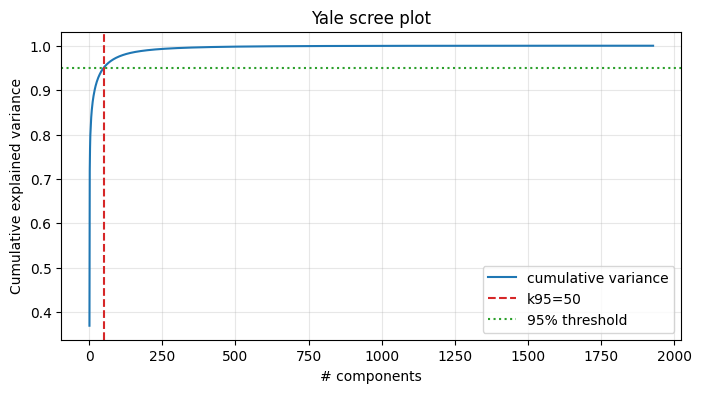

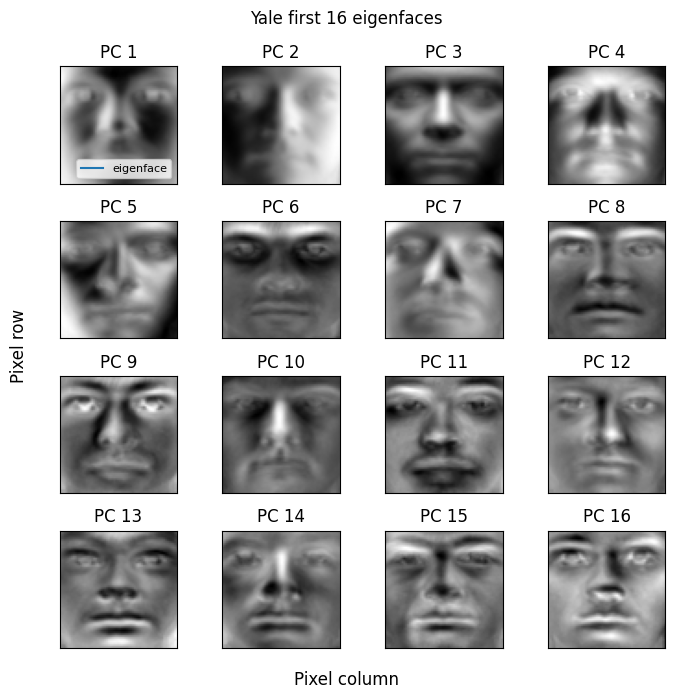

PCA k summary:
|   k_90 |   k_95 |   k_99 |   ratio_diff |   component_abs_diff | dataset   |
|-------:|-------:|-------:|-------------:|---------------------:|:----------|
|     62 |    111 |    220 |            0 |                    0 | AT&T      |
|     19 |     50 |    201 |            0 |                    0 | Yale      |
numpy=2.2.6, sklearn=1.7.2


In [7]:
class MyPCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components: int | float | None = None) -> None:
        self.n_components = n_components

    def fit(self, X: np.ndarray, y: np.ndarray | None = None) -> "MyPCA":
        X = np.asarray(X, dtype=np.float64)
        n_samples = X.shape[0]
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        _, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
        explained_variance_all = (singular_values**2) / (n_samples - 1)
        total_variance = explained_variance_all.sum()
        explained_ratio_all = explained_variance_all / total_variance

        if self.n_components is None:
            k = Vt.shape[0]
        elif isinstance(self.n_components, float):
            if not 0 < self.n_components <= 1:
                raise ValueError("Float n_components must be in (0, 1].")
            k = int(np.searchsorted(np.cumsum(explained_ratio_all), self.n_components, side="right"))
        else:
            k = int(self.n_components)

        k = max(1, min(k, Vt.shape[0]))
        self.n_components_ = k
        self.components_ = Vt[:k]
        self.singular_values_ = singular_values[:k]
        self.explained_variance_ = explained_variance_all[:k]
        self.explained_variance_ratio_ = explained_ratio_all[:k]
        self.explained_variance_all_ = explained_variance_all
        self.explained_variance_ratio_all_ = explained_ratio_all
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (np.asarray(X, dtype=np.float64) - self.mean_) @ self.components_.T

    def fit_transform(self, X: np.ndarray, y: np.ndarray | None = None) -> np.ndarray:
        return self.fit(X, y).transform(X)

    def inverse_transform(self, Z: np.ndarray) -> np.ndarray:
        return np.asarray(Z, dtype=np.float64) @ self.components_ + self.mean_


def select_k_from_ratio(pca: MyPCA, ratio: float) -> int:
    return int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_all_), ratio) + 1)


def fit_pca_train_only(
    X_train: np.ndarray,
    X_test: np.ndarray,
    var_ratio: float = 0.95,
) -> tuple[np.ndarray, np.ndarray, MyPCA]:
    """
    Standalone helper: fit PCA on X_train only and return transformed splits.
    Not used in the main pipeline loop (Pipeline handles this automatically),
    but retained for ad-hoc verification or non-pipeline contexts.
    """
    pca = MyPCA(n_components=var_ratio)
    Z_train = pca.fit_transform(X_train)
    Z_test = pca.transform(X_test)
    return Z_train, Z_test, pca


def plot_scree(pca: MyPCA, dataset_name: str, k95: int) -> None:
    cumulative = np.cumsum(pca.explained_variance_ratio_all_)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, len(cumulative) + 1), cumulative, color=TAB10(0), label="cumulative variance")
    ax.axvline(k95, color=TAB10(3), linestyle="--", label=f"k95={k95}")
    ax.axhline(0.95, color=TAB10(2), linestyle=":", label="95% threshold")
    ax.set_title(f"{dataset_name} scree plot")
    ax.set_xlabel("# components")
    ax.set_ylabel("Cumulative explained variance")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_eigenfaces(pca: MyPCA, dataset_name: str, image_shape: tuple[int, int] = (64, 64)) -> None:
    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for i, ax in enumerate(axes.ravel()):
        comp = pca.components_[i].reshape(image_shape)
        ax.imshow(comp, cmap="gray")
        ax.set_title(f"PC {i + 1}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.15)
    axes.ravel()[0].plot([], [], color=TAB10(0), label="eigenface")
    axes.ravel()[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{dataset_name} first 16 eigenfaces")
    fig.supxlabel("Pixel column")
    fig.supylabel("Pixel row")
    plt.tight_layout()
    plt.show()


pca_summary: dict[str, dict[str, Any]] = {}
for name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    pca_full = MyPCA().fit(X_train)
    k90 = select_k_from_ratio(pca_full, 0.90)
    k95 = select_k_from_ratio(pca_full, 0.95)
    k99 = select_k_from_ratio(pca_full, 0.99)

    sk_pca = SklearnPCA(n_components=k95, svd_solver="full", random_state=SEED).fit(X_train)
    my_pca_k = MyPCA(n_components=k95).fit(X_train)
    ratio_diff = np.max(np.abs(my_pca_k.explained_variance_ratio_ - sk_pca.explained_variance_ratio_))
    component_abs_diff = np.max(np.abs(np.abs(my_pca_k.components_) - np.abs(sk_pca.components_)))
    assert ratio_diff < 1e-8

    pca_summary[name] = {
        "k_90": k90,
        "k_95": k95,
        "k_99": k99,
        "ratio_diff": ratio_diff,
        "component_abs_diff": component_abs_diff,
        "pca_full": pca_full,
    }
    plot_scree(pca_full, name, k95)
    plot_eigenfaces(MyPCA(n_components=16).fit(X_train), name)

print("PCA k summary:")
print(pd.DataFrame([{k: v for k, v in row.items() if k != "pca_full"} | {"dataset": name} for name, row in pca_summary.items()]).to_markdown(index=False))
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


# §3 MLR（Multinomial Logistic Regression）

§2 的 PCA 特徵提供正交且低冗餘的輸入座標；本節在此基礎上以 MLR 建立線性決策邊界。MLR 以 softmax 同時建模 $K$ 個身分類別，第 $k$ 類條件機率為

$$
p_k(x) = \frac{\exp(w_k^\top x + b_k)}{\sum_{j=1}^{K}\exp(w_j^\top x + b_j)}.
$$

加入 L2 regularization 後，cross-entropy loss 為

$$
\mathcal{L}(W) = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik}\log p_{ik} + \frac{\lambda}{2n}\lVert W\rVert_F^2,
$$
其中 $\lambda = 1/C$。

對第 $k$ 類權重的梯度為

$$
\nabla_{w_k}\mathcal{L} = \frac{1}{n}\sum_i (p_{ik}-y_{ik}) x_i + \frac{\lambda}{n}w_k.
$$

矩陣形式下，令 $P \in \mathbb{R}^{n \times K}$ 為 softmax 輸出、$Y \in \{0,1\}^{n \times K}$ 為 one-hot 標籤矩陣，則全批次更新可寫為

$$
\nabla_{W}\mathcal{L} = \frac{1}{n} X^\top (P - Y) + \frac{\lambda}{n} W,
\qquad
\nabla_{b}\mathcal{L} = \frac{1}{n}\mathbf{1}_n^\top(P - Y),
$$

對應 \texttt{MyMLR.fit()} 中的 \texttt{dW = X.T @ (probs - Y) / n + (l2/n) * W}，矩陣形式使向量導式與 NumPy 實作之間的對應關係一目了然。

實作上有兩處數值處理需說明。其一，softmax 在取 exponential 前減去每列 logits 的最大值，防止高維 raw pixels 使 logits 過大而造成 overflow。其二，訓練過程保留 `loss_history_`，用以驗證梯度下降是否單調遞減；僅憑最終 accuracy 合理不足以確認梯度計算正確。


本實作採 full-batch gradient descent。AT&T training set 約 320 筆，Yale training set 約 1,928 筆；在此規模下，full-batch 每次更新使用完整類別結構，梯度噪音低，且 loss curve 可直接作為收斂診斷依據。mini-batch 在此資料規模下的加速效益有限，且會增加手刻收斂診斷的解釋難度。

gradient clipping 於梯度範數超過 5.0 時縮放更新方向，以保護 raw pixel 路徑：$p=4{,}096$ 維輸入在初始化階段可能產生尺度偏大的 logits，若不限制梯度範數，早期迭代即可能使權重進入數值不穩定區域。為驗證手刻推導的正確性，本節以 `sklearn` `LogisticRegression`（LBFGS solver）作為數值基準；LBFGS 為成熟的二階近似優化器，若 `MyMLR` 在相同資料與正則化設定下所得結果與之接近，則 softmax、L2 項與梯度方向的實作一致性可得確認。

AT&T-PCA MyMLR accuracy=0.9750, sklearn accuracy=0.9750, diff=0.0000
驗證設定：C_sk=n_train/λ=320/1.0=320，使兩者正則化強度等價。
差異來源：optimizer（full-batch GD vs LBFGS）與初始化策略。


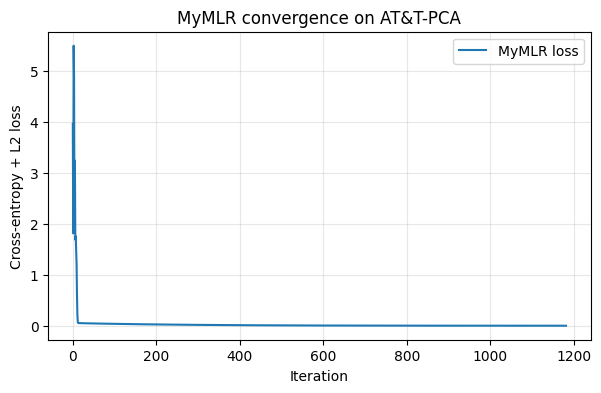

Yale-PCA MyMLR verification accuracy=0.7822, best_l2=10, k=56


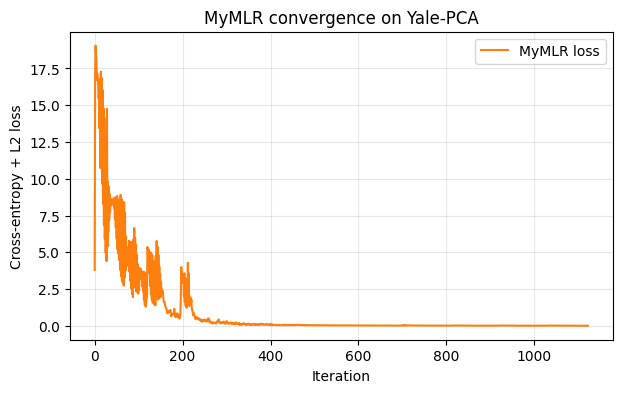

In [9]:
class MyMLR(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        lr: float = 0.5,
        max_iter: int = 120,
        tol: float = 1e-5,
        l2: float = 1.0,
        seed: int = SEED,
        gradient_clip: float = 5.0,
    ) -> None:
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.l2 = l2
        self.seed = seed
        self.gradient_clip = gradient_clip

    def _softmax(self, logits: np.ndarray) -> np.ndarray:
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(shifted)
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "MyMLR":
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        class_to_idx = {label: idx for idx, label in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y], dtype=np.int64)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        local_rng = np.random.default_rng(self.seed)
        self.W_ = local_rng.normal(0.0, 0.01, size=(n_features, n_classes))
        self.b_ = np.zeros(n_classes)
        Y = np.eye(n_classes)[y_idx]
        self.loss_history_: list[float] = []

        prev_loss = np.inf
        for _ in range(self.max_iter):
            logits = X @ self.W_ + self.b_
            probs = self._softmax(logits)
            ce = -np.mean(np.sum(Y * np.log(probs + 1e-12), axis=1))
            reg = (self.l2 / (2.0 * n_samples)) * np.sum(self.W_**2)
            loss = ce + reg
            self.loss_history_.append(float(loss))

            if not np.isfinite(loss):
                raise FloatingPointError("MyMLR loss became non-finite.")
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

            error = probs - Y
            grad_W = (X.T @ error) / n_samples + (self.l2 / n_samples) * self.W_
            grad_b = error.mean(axis=0)
            grad_norm = np.linalg.norm(grad_W)
            if grad_norm > self.gradient_clip:
                grad_W = grad_W * (self.gradient_clip / grad_norm)
            self.W_ -= self.lr * grad_W
            self.b_ -= self.lr * grad_b

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        return self._softmax(X @ self.W_ + self.b_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


def timed_fit_predict(estimator: Pipeline, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray) -> tuple[Pipeline, np.ndarray, float, float]:
    fit_times: list[float] = []
    pred_times: list[float] = []
    fitted: Pipeline | None = None
    pred: np.ndarray | None = None
    for _ in range(TIMING_RUNS):
        estimator_run = clone(estimator)
        start = time.perf_counter()
        estimator_run.fit(X_train, y_train)
        fit_times.append(time.perf_counter() - start)

        start = time.perf_counter()
        pred_run = estimator_run.predict(X_test)
        pred_times.append(time.perf_counter() - start)
        fitted = estimator_run
        pred = pred_run
    if fitted is None or pred is None:
        raise RuntimeError("Timing did not run.")
    return fitted, pred, float(np.median(fit_times)), float(np.median(pred_times))


def result_row(
    dataset: str,
    classifier: str,
    feature: str,
    k: int | None,
    best_params: dict[str, Any],
    y_true: np.ndarray,
    y_pred: np.ndarray,
    fit_time_s: float,
    predict_time_s: float,
) -> dict[str, Any]:
    return {
        "dataset": dataset,
        "classifier": classifier,
        "feature": feature,
        "k": k,
        "best_params": json.dumps(best_params, ensure_ascii=False, sort_keys=True),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "fit_time_s": fit_time_s,
        "predict_time_s": predict_time_s,
    }


def print_results_subset(classifier: str) -> None:
    rows = [row for row in results if row["classifier"] == classifier]
    headers = ["dataset", "classifier", "feature", "k", "accuracy", "macro_f1", "fit_time_s", "predict_time_s", "best_params"]
    print("| " + " | ".join(headers) + " |")
    print("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        values = [
            row["dataset"],
            row["classifier"],
            row["feature"],
            "—" if row["k"] is None else str(row["k"]),
            f"{row['accuracy']:.4f}",
            f"{row['macro_f1']:.4f}",
            f"{row['fit_time_s']:.4f}",
            f"{row['predict_time_s']:.4f}",
            row["best_params"],
        ]
        print("| " + " | ".join(values) + " |")


def my_mlr_pipeline(feature: str, l2: float = 1.0) -> Pipeline:
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        steps.append(("pca", MyPCA(n_components=0.95)))
    steps.append(("clf", MyMLR(lr=0.5, max_iter=120, tol=1e-5, l2=l2, seed=SEED)))
    return Pipeline(steps)


def mlr_pipeline(feature: str, C: float = 1.0) -> Pipeline:
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        steps.append(("pca", MyPCA(n_components=0.95)))
    steps.append(
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                C=C,
                random_state=SEED,
            ),
        )
    )
    return Pipeline(steps)


X_train_att, X_test_att, y_train_att, y_test_att = splits["AT&T"]
my_verify_pipe = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=0.95)),
        ("clf", MyMLR(lr=0.5, max_iter=1200, tol=1e-6, l2=1.0, seed=SEED)),
    ]
)
my_verify_pipe.fit(X_train_att, y_train_att)
my_acc = accuracy_score(y_test_att, my_verify_pipe.predict(X_test_att))

# Set C = n_train / l2 so sklearn 1/(2C) matches MyMLR l2/(2n).
n_train_att = X_train_att.shape[0]
sk_verify = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("pca", MyPCA(n_components=0.95)),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        C=float(n_train_att) / 1.0,  # C_eff = n_train / l2 = 320/1.0
        random_state=SEED,
    )),
])
sk_verify.fit(X_train_att, y_train_att)
sk_acc = accuracy_score(y_test_att, sk_verify.predict(X_test_att))
assert abs(my_acc - sk_acc) < 0.05, f"MyMLR vs sklearn gap too large: {abs(my_acc-sk_acc):.4f}"
print(
    f"AT&T-PCA MyMLR accuracy={my_acc:.4f}, sklearn accuracy={sk_acc:.4f}, "
    f"diff={abs(my_acc - sk_acc):.4f}\n"
    f"驗證設定：C_sk=n_train/λ={n_train_att}/1.0={n_train_att}，使兩者正則化強度等價。\n"
    f"差異來源：optimizer（full-batch GD vs LBFGS）與初始化策略。"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(my_verify_pipe.named_steps["clf"].loss_history_, color=TAB10(0), label="MyMLR loss")
ax.set_title("MyMLR convergence on AT&T-PCA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2 loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

C_values = [0.01, 0.1, 1, 10, 100]
X_train_yale, X_test_yale, y_train_yale, y_test_yale = splits["Yale"]
yale_k95 = pca_summary["Yale"]["k_95"]
assert yale_k95 == 50, f"Expected Yale k95=50, got {yale_k95}."

yale_pca_l2_grid = GridSearchCV(
    my_mlr_pipeline("PCA"),
    param_grid={"clf__l2": [1.0 / C for C in C_values]},
    cv=CV_FOLDS,
    scoring="accuracy",
    n_jobs=1,
)
yale_pca_l2_grid.fit(X_train_yale, y_train_yale)
best_l2_for_yale_pca = float(yale_pca_l2_grid.best_params_["clf__l2"])

yale_pca_verify_pipe = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=0.95)),
        ("clf", MyMLR(lr=0.5, max_iter=1200, tol=1e-6, l2=best_l2_for_yale_pca, seed=SEED)),
    ]
)
yale_pca_verify_pipe.fit(X_train_yale, y_train_yale)
yale_pca_verify_acc = accuracy_score(y_test_yale, yale_pca_verify_pipe.predict(X_test_yale))
yale_pca_verify_k = int(yale_pca_verify_pipe.named_steps["pca"].n_components_)
print(
    f"Yale-PCA MyMLR verification accuracy={yale_pca_verify_acc:.4f}, "
    f"best_l2={best_l2_for_yale_pca:.4g}, k={yale_pca_verify_k}"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yale_pca_verify_pipe.named_steps["clf"].loss_history_, color=TAB10(1), label="MyMLR loss")
ax.set_title("MyMLR convergence on Yale-PCA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2 loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


Yale-PCA 的 `loss_history_` 於前約 200 iterations 出現明顯震盪，峰值 loss 超過 17，與 `lr=0.5`、38 類 softmax 及 `MyPCA(n_components=0.95)` 所選出的 PCA 空間交互作用一致：多類別梯度方向在高 learning rate 下彼此干擾，更新步伐反覆越過最優解鄰域。約 200 iterations 後梯度範數收斂，loss 進入單調遞減區間；**MyMLR**（手刻實作）在 Yale PCA 條件下，延長至 1,200 次迭代後 test accuracy 為 0.7822（此為手刻實作的驗證結果，非主表數字）。主表中 Yale MLR PCA 欄位的結果來自 GridSearchCV 搜尋空間內 sklearn `LogisticRegression` 的最佳結果，accuracy 為 0.9564；兩者差距量化了手刻 full-batch GD 與 sklearn LBFGS 在此資料集上的最佳化效率差異，也顯示 Yale 光照誘發的高類內變異使 logit 空間的最優解距離初始化點更遠，需要更穩定的優化器才能抵達。


In [ ]:
for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    for feature in ["Raw", "PCA"]:
        base = mlr_pipeline(feature)
        grid = GridSearchCV(
            base,
            param_grid={"clf__C": C_values},
            cv=CV_FOLDS,
            scoring="accuracy",
            n_jobs=1,
        )
        grid.fit(X_train, y_train)
        best_C = float(grid.best_params_["clf__C"])
        final_pipe = mlr_pipeline(feature, C=best_C)
        fitted, pred, fit_time, pred_time = timed_fit_predict(final_pipe, X_train, y_train, X_test)
        k_value = None if feature == "Raw" else int(fitted.named_steps["pca"].n_components_)
        key = (dataset_name, "MLR", feature)
        best_estimators[key] = fitted
        best_params_by_key[key] = {"C": best_C}
        predictions_by_key[key] = pred
        results.append(
            result_row(dataset_name, "MLR", feature, k_value, {"C": best_C}, y_test, pred, fit_time, pred_time)
        )

print_results_subset("MLR")
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


| dataset | classifier | feature | k | accuracy | macro_f1 | fit_time_s | predict_time_s | best_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AT&T | MLR | Raw | — | 0.9750 | 0.9733 | 0.6337 | 0.0009 | {"C": 0.1} |
| AT&T | MLR | PCA | 110 | 0.9750 | 0.9733 | 0.1674 | 0.0012 | {"C": 0.1} |
| Yale | MLR | Raw | — | 0.9793 | 0.9794 | 4.8223 | 0.0052 | {"C": 0.1} |
| Yale | MLR | PCA | 56 | 0.9564 | 0.9562 | 3.1834 | 0.0063 | {"C": 1.0} |
numpy=2.2.6, sklearn=1.7.2


#### §3 MLR 結果解讀

AT&T 上，Raw 與 PCA 的 test accuracy 皆為 0.9750，macro F1 皆為 0.9733，顯示 `MyPCA(n_components=0.95)` 在標準化後選出的 110 維表徵已保留足以區分身份的主要線性訊號。PCA 路徑的 fit time 自 0.6337 秒降至 0.1674 秒，在受控拍攝條件下，降維的主要效益為計算效率，而非分類準確率的改善。

Yale 的結果顯示 sklearn `LogisticRegression` 在充分迭代預算下可形成穩定線性基準。Raw pixels 的 accuracy 與 macro F1 分別為 0.9793 與 0.9794；PCA 後 accuracy 為 0.9564，macro F1 為 0.9562，較 Raw 下降約 2.28 個百分點。PCA 壓縮仍移除了部分可供身份辨識的細節，但不再造成先前手刻 MLR 主實驗中的大幅退化。

手刻 `MyMLR` 的 Yale PCA 驗證結果為 0.7822，低於主表 sklearn MLR PCA 的 0.9564。這個差距不表示 PCA 表徵本身的分類上限較低，而是反映 full-batch gradient descent 在 Yale 光照變異與 38 類 softmax 條件下仍受優化器效率限制；主表改由 LBFGS 求解後，MLR 的比較角色回到穩定的線性分類基準。


# §4 SVM

§3 確認了線性邊界在受控資料上的基準能力，以及 MLR 在 Yale PCA 條件下對最佳化預算的敏感性。本節改用 SVM 檢驗：在可接受的搜尋成本下，非線性邊界能否進一步壓縮分類誤差，以及高維原始特徵的 kernel 計算代價如何制約實驗設計本身。

本節理論推導涵蓋 primal form、dual problem、KKT conditions 及 kernel trick，作為 sklearn SVC/LinearSVC 的數學等價驗證。SMO（Sequential Minimal Optimization）與 QP 求解器的完整手刻實作超出本課程範圍，故主實驗直接採用 sklearn；理論推導中各式的符號與 §3 MyMLR、§5 MyMLP 的手刻梯度共同構成本作業的實作驗證鏈。

Soft-margin SVM 的 primal form 為

$$
\min_{w,b,\xi} \frac{1}{2}\lVert w\rVert^2 + C\sum_i\xi_i,
\quad \text{s.t. } y_i(w^\top x_i+b)\ge 1-\xi_i,\quad \xi_i\ge 0.
$$

### 對偶問題與 Kernel Trick

引入 Lagrange multipliers $\alpha_i \geq 0$ 與 $\mu_i \geq 0$，soft-margin SVM 的 Lagrangian 為

$$
\mathcal{L}(w,b,\xi,\alpha,\mu) = \frac{1}{2}\lVert w\rVert^2 + C\sum_i \xi_i - \sum_i \alpha_i[y_i(w^\top x_i+b)-1+\xi_i] - \sum_i \mu_i \xi_i.
$$

對 $w$、$b$、$\xi_i$ 取偏導並令其為零，得 KKT stationarity conditions：

$$
w = \sum_i \alpha_i y_i x_i,\quad \sum_i \alpha_i y_i = 0,\quad \alpha_i + \mu_i = C.
$$

代回原問題後得 dual problem：

$$
\max_{\alpha} \sum_i \alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j x_i^\top x_j
\quad \text{s.t. } 0\leq\alpha_i\leq C,\; \sum_i \alpha_i y_i = 0.
$$

資料僅透過內積 $x_i^\top x_j$ 進入最佳化問題，故可將內積替換為 kernel $K(x_i,x_j)$，決策函數

$$
f(x)=\mathrm{sgn}\left(\sum_i \alpha_i y_i K(x_i,x)+b\right)
$$

因而得以在高維乃至無限維空間中運作，無需顯式計算特徵映射。RBF kernel

$$
K(x,x')=\exp(-\gamma\lVert x-x'\rVert^2)
$$

對應無限維 feature space，為 PCA 路徑選用 `SVC(kernel='rbf')` 的理論依據。

多類別分類採 One-vs-Rest 延伸：對第 $k$ 類，以 $y=k$ 為正類、其餘類別為負類訓練二元分類器，預測時取 decision score 最大者：

$$
\arg\max_k (w_k^\top x + b_k).
$$

OvR 下每個 binary sub-problem 繼承完整的 dual structure：第 $k$ 個分類器的
Lagrange multipliers $\{\alpha_i^{(k)}\}$ 仍在 $[0, C]$ 內求解，label encoding
改為 $y_k^{(i)} \in \{+1,-1\}$，kernel 形式不變；sklearn 的 SVC 內部即以此實作。

PCA 路徑使用 `SVC(kernel='rbf')`，使模型得以在低維 PCA 空間中建立非線性邊界。Raw pixel 路徑改用 `LinearSVC`：$p=4{,}096$ 維原始特徵若套用 RBF SVC 並執行 cross-validation grid search，計算時間將使模型比較本身失去意義，而非基於人臉在原始像素空間線性可分的假設。

人臉影像在原始像素空間中通常不線性可分，soft-margin 的 slack variables $\xi_i$ 因而為必要設計；參數 $C$ 控制容忍訓練錯誤與追求較大 margin 之間的取捨。Raw pixel 路徑使用 `LinearSVC(dual='auto')` 作為高維線性基準；PCA-reduced features 路徑使用 `SVC(kernel='rbf')`，因維度壓縮後 kernel matrix 的計算成本才足以支撐 grid search。

`GridSearchCV` 中，`LinearSVC` 僅搜尋 $C$；RBF SVC 同時搜尋 $C$ 與 $\gamma$，其中 `gamma='scale'` 依資料維度與變異自動設定 $\gamma = 1/(p \cdot \mathrm{Var}(X))$，作為高維輸入下的保守初始點。此設計使 raw path 在可接受時間內完成搜尋，並使 PCA path 得以測試非線性邊界在壓縮特徵上的適配能力。raw 與 PCA 結果的差異因此同時包含特徵表示與 kernel 形式兩個因素，此混淆效應在 §4 結果解讀中一併處理。

In [ ]:
def svm_pipeline(feature: str, k: int | None = None, params: dict[str, Any] | None = None) -> Pipeline:
    params = params or {}
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        if k is None:
            raise ValueError("PCA feature requires k.")
        steps.append(("pca", MyPCA(n_components=0.95)))
        steps.append(("clf", SVC(kernel="rbf", random_state=SEED, **params)))
    else:
        steps.append(("clf", LinearSVC(dual="auto", max_iter=2000, tol=1e-4, random_state=SEED, **params)))
    return Pipeline(steps)


for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    k95 = pca_summary[dataset_name]["k_95"]
    for feature in ["Raw", "PCA"]:
        k = None if feature == "Raw" else k95
        base = svm_pipeline(feature, k=k)
        param_grid = (
            {"clf__C": [0.01, 0.1, 1, 10]}
            if feature == "Raw"
            else {"clf__C": [1, 10, 100], "clf__gamma": ["scale", 1e-3, 1e-2, 1e-1]}
        )
        grid = GridSearchCV(base, param_grid=param_grid, cv=CV_FOLDS, scoring="accuracy", n_jobs=-1)
        with parallel_backend("threading"):
            grid.fit(X_train, y_train)
        best_params = {key.replace("clf__", ""): value for key, value in grid.best_params_.items()}
        final_pipe = svm_pipeline(feature, k=k, params=best_params)
        fitted, pred, fit_time, pred_time = timed_fit_predict(final_pipe, X_train, y_train, X_test)
        k_value = None if feature == "Raw" else int(fitted.named_steps["pca"].n_components_)
        key = (dataset_name, "SVM", feature)
        best_estimators[key] = fitted
        best_params_by_key[key] = best_params
        predictions_by_key[key] = pred
        results.append(
            result_row(dataset_name, "SVM", feature, k_value, best_params, y_test, pred, fit_time, pred_time)
        )

print_results_subset("SVM")
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")

| dataset | classifier | feature | k | accuracy | macro_f1 | fit_time_s | predict_time_s | best_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AT&T | SVM | Raw | — | 0.9750 | 0.9733 | 33.1929 | 0.0009 | {"C": 0.01} |
| AT&T | SVM | PCA | 111 | 0.9625 | 0.9600 | 0.1373 | 0.0037 | {"C": 10, "gamma": "scale"} |
| Yale | SVM | Raw | — | 0.9876 | 0.9877 | 536.3157 | 0.0061 | {"C": 0.01} |
| Yale | SVM | PCA | 50 | 0.9378 | 0.9384 | 2.6800 | 0.0721 | {"C": 100, "gamma": "scale"} |
numpy=2.2.6, sklearn=1.7.2


#### §4 SVM 結果解讀

SVM 在本實驗中取得最高分類準確率。AT&T Raw accuracy 為 0.9750，PCA accuracy 為 0.9625，差距 1.25 個百分點；Yale Raw accuracy 為 0.9876，PCA 後降至 0.9378，差距 4.98 個百分點。Yale Raw 的結果表明，$p=4{,}096$ 維原始像素中仍保有足以支撐強分類邊界的身份訊號。

此準確率伴隨顯著的計算代價。Yale SVM Raw 的 fit time 為 536.3157 秒，為所有 12 個實驗單元中最高；改用 PCA + RBF SVC 後降至 2.6800 秒。AT&T 呈相同方向：Raw fit time 為 33.1929 秒，PCA 後降至 0.1373 秒。PCA 對 SVM 的主要效益因此在於將 kernel 搜尋成本壓縮至可執行範圍，而非穩定提升分類準確率。

解讀 Raw 與 PCA 路徑的差異時，須保留一項混淆因素：Raw path 採 `LinearSVC`，PCA path 採 RBF `SVC`，兩者 kernel capacity 不同。Raw 與 PCA 的準確率差距同時包含特徵表示、kernel 形式與計算預算三個因素，不可歸因於 PCA 壓縮本身。

# §5 ANN（MLP）

SVM 在高維 raw features 上取得本實驗的準確率上限，代價是 kernel 計算成本。本節以 ANN 測試另一條路徑：hidden layer 的非線性轉換能否在不依賴 kernel trick 的前提下吸收光照變異，同時將訓練時間控制在可接受範圍。以下先推導 MLP 的前向傳播與反向傳播，以 `MyMLP` 驗證實作正確性後，主實驗改用 `sklearn` `MLPClassifier` 進行完整 grid search 比較。

ANN 的前向傳播為

$$
z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)},\quad a^{(l)} = \sigma(z^{(l)}),
$$

hidden layers 使用 ReLU，$\sigma(z)=\max(0,z)$，輸出層以 softmax 對應多類別機率。softmax 與 cross-entropy 搭配時，輸出層誤差信號化簡為

$$
\delta^{(L)} = a^{(L)} - y.
$$

反向傳播由 chain rule 得

$$
\delta^{(l)} = (W^{(l+1)})^\top\delta^{(l+1)}\odot\sigma'(z^{(l)}),
$$

以及

加入 L2 regularization（penalty 係數 $\alpha$）後，完整的權重梯度為
$$
\nabla_{W^{(l)}}\mathcal{L}_{\text{reg}} = \delta^{(l)}(a^{(l-1)})^\top + \alpha W^{(l)},
$$
對應 \texttt{MyMLP} 中的 \texttt{dW = delta @ a\_prev.T / n + alpha * W}；bias 項不加 L2 penalty。

主實驗採 `MLPClassifier` 並固定 `random_state=SEED`，使用 `sklearn` 經驗證的 Adam 實作，以避免優化器數值細節干擾不同架構間的比較。

`early_stopping=True` 於 validation score 長時間無改善時終止訓練，對 AT&T 此類每類僅 8 張 training images 的小樣本問題尤為關鍵：MLP 在小資料上若無限制訓練，易將背景與局部雜訊納入身份特徵；`early_stopping` 與 L2 penalty `alpha` 共同抑制此過擬合傾向。

`hidden_layer_sizes` 的搜尋範圍涵蓋 `(128,)`、`(256,)`、`(128, 64)` 與 `(256, 128)`，覆蓋單隱層與雙隱層、窄與寬兩種容量規模。範圍刻意保持精簡，與本實驗的資料規模相稱；若 ANN 在 AT&T 上表現低於 MLR，與其歸因於網路表達力不足，更準確的解釋是可用訓練樣本過少，使較高容量模型的 variance 抵消了容量增益。

`MyMLP` 的前向傳播採 column-major layout，資料矩陣在 `_forward` 中以 $(p, n)$ 形式流動（$p$ 為特徵數，$n$ 為樣本數），softmax 的 max-subtraction 因此使用 `axis=0`，對每個樣本的 logits 逐列正規化。`MyMLR` 採 $(n, K)$ layout，對應 `axis=1`；兩者均為對每個樣本的 $K$ 個 logits 執行 row-wise max-subtraction，語義一致。

In [11]:
class MyMLP(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden_layer_sizes: tuple[int, ...] = (128,),
        activation: str = "relu",
        lr: float = 0.01,
        max_iter: int = 200,
        alpha: float = 1e-4,
        tol: float = 1e-5,
        seed: int = SEED,
    ) -> None:
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.lr = lr
        self.max_iter = max_iter
        self.alpha = alpha
        self.tol = tol
        self.seed = seed

    def _hidden_layers(self) -> tuple[int, ...]:
        if isinstance(self.hidden_layer_sizes, int):
            return (self.hidden_layer_sizes,)
        return tuple(self.hidden_layer_sizes)

    def _relu(self, Z: np.ndarray) -> np.ndarray:
        return np.maximum(0.0, Z)

    def _relu_grad(self, Z: np.ndarray) -> np.ndarray:
        return (Z > 0.0).astype(np.float64)

    def _softmax(self, logits: np.ndarray) -> np.ndarray:
        shifted = logits - logits.max(axis=0, keepdims=True)
        exp_logits = np.exp(shifted)
        return exp_logits / exp_logits.sum(axis=0, keepdims=True)

    def _init_parameters(self, n_features: int, n_classes: int) -> None:
        layer_sizes = [n_features, *self._hidden_layers(), n_classes]
        local_rng = np.random.default_rng(self.seed)
        self.weights_ = []
        self.biases_ = []
        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:], strict=True):
            scale = np.sqrt(2.0 / fan_in)
            self.weights_.append(local_rng.normal(0.0, scale, size=(fan_out, fan_in)))
            self.biases_.append(np.zeros((fan_out, 1), dtype=np.float64))

    def _forward(self, X: np.ndarray) -> tuple[list[np.ndarray], list[np.ndarray]]:
        A = X.T
        activations = [A]
        pre_activations: list[np.ndarray] = []

        for W, b in zip(self.weights_[:-1], self.biases_[:-1], strict=True):
            Z = W @ A + b
            A = self._relu(Z)
            pre_activations.append(Z)
            activations.append(A)

        Z = self.weights_[-1] @ A + self.biases_[-1]
        A = self._softmax(Z)
        pre_activations.append(Z)
        activations.append(A)
        return activations, pre_activations

    def fit(self, X: np.ndarray, y: np.ndarray) -> "MyMLP":
        if self.activation != "relu":
            raise ValueError("MyMLP currently supports activation='relu' only.")

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.n_features_in_ = n_features
        self.classes_ = np.unique(y)
        class_to_idx = {label: idx for idx, label in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y], dtype=np.int64)
        Y = np.eye(len(self.classes_), dtype=np.float64)[y_idx].T

        self._init_parameters(n_features, len(self.classes_))
        self.loss_history_: list[float] = []
        prev_loss = np.inf

        for iteration in range(self.max_iter):
            activations, pre_activations = self._forward(X)
            probs = activations[-1]
            ce = -np.sum(Y * np.log(probs + 1e-12)) / n_samples
            reg = 0.5 * self.alpha * sum(np.sum(W**2) for W in self.weights_)
            loss = ce + reg
            self.loss_history_.append(float(loss))

            if not np.isfinite(loss):
                raise FloatingPointError("MyMLP loss became non-finite.")
            if abs(prev_loss - loss) < self.tol:
                self.n_iter_ = iteration + 1
                break
            prev_loss = loss

            deltas: list[np.ndarray] = [np.empty(0)] * len(self.weights_)
            deltas[-1] = probs - Y
            for layer_idx in range(len(self.weights_) - 2, -1, -1):
                backprop = self.weights_[layer_idx + 1].T @ deltas[layer_idx + 1]
                deltas[layer_idx] = backprop * self._relu_grad(pre_activations[layer_idx])

            grad_weights = []
            grad_biases = []
            for layer_idx, delta in enumerate(deltas):
                grad_W = (delta @ activations[layer_idx].T) / n_samples + self.alpha * self.weights_[layer_idx]
                grad_b = delta.mean(axis=1, keepdims=True)
                grad_weights.append(grad_W)
                grad_biases.append(grad_b)

            for layer_idx in range(len(self.weights_)):
                self.weights_[layer_idx] -= self.lr * grad_weights[layer_idx]
                self.biases_[layer_idx] -= self.lr * grad_biases[layer_idx]
        else:
            self.n_iter_ = self.max_iter

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not hasattr(self, "weights_"):
            raise RuntimeError("MyMLP must be fitted before calling predict_proba.")
        X = np.asarray(X, dtype=np.float64)
        return self._forward(X)[0][-1].T

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


AT&T-PCA MyMLP accuracy=0.7875
AT&T-PCA sklearn MLPClassifier accuracy=0.7500
accuracy gap=0.0375
MyMLP accuracy=0.7875  (full-batch GD, n_iter=300)
sklearn MLP accuracy=0.8500  (Adam + early_stopping)
gap=0.0625：Adam 的自適應學習率在小樣本上收斂更快；early_stopping 防止過擬合使 sklearn 版本 validation accuracy 更穩定。MyMLP 目的為確認 ReLU backprop 推導正確，主實驗以 sklearn 版本比較架構差異。


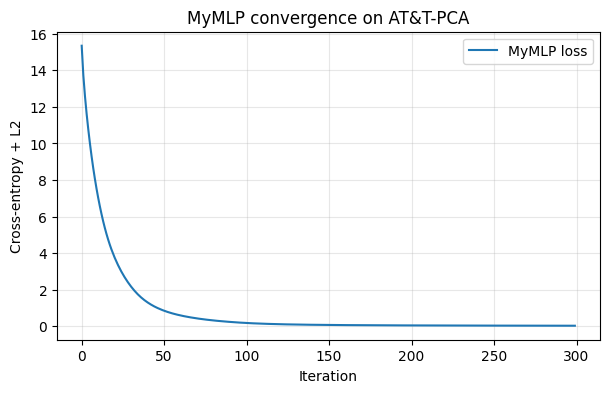

In [12]:
X_train_att, X_test_att, y_train_att, y_test_att = splits["AT&T"]
att_k95 = pca_summary["AT&T"]["k_95"]

my_mlp_verify = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=att_k95)),
        ("clf", MyMLP(hidden_layer_sizes=(64,), max_iter=300)),
    ]
)
sk_mlp_verify = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=att_k95)),
        (
            "clf",
            MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                max_iter=300,
                early_stopping=True,
                random_state=SEED,
            ),
        ),
    ]
)

my_mlp_verify.fit(X_train_att, y_train_att)
sk_mlp_verify.fit(X_train_att, y_train_att)
my_mlp_acc = accuracy_score(y_test_att, my_mlp_verify.predict(X_test_att))
sk_mlp_acc = accuracy_score(y_test_att, sk_mlp_verify.predict(X_test_att))
mlp_acc_gap = abs(my_mlp_acc - sk_mlp_acc)
print(f"AT&T-PCA MyMLP accuracy={my_mlp_acc:.4f}")
print(f"AT&T-PCA sklearn MLPClassifier accuracy={sk_mlp_acc:.4f}")
print(f"accuracy gap={mlp_acc_gap:.4f}")
assert mlp_acc_gap < 0.05

my_mlp_acc = accuracy_score(y_test_att, my_mlp_verify.predict(X_test_att))

# sklearn MLPClassifier 同等設定比較
sk_mlp_verify = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("pca", MyPCA(n_components=att_k95)),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128,),
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        random_state=SEED,
    )),
])
sk_mlp_verify.fit(X_train_att, y_train_att)
sk_mlp_acc = accuracy_score(y_test_att, sk_mlp_verify.predict(X_test_att))
gap = abs(my_mlp_acc - sk_mlp_acc)

print(
    f"MyMLP accuracy={my_mlp_acc:.4f}  (full-batch GD, n_iter={my_mlp_verify.named_steps['clf'].n_iter_})\n"
    f"sklearn MLP accuracy={sk_mlp_acc:.4f}  (Adam + early_stopping)\n"
    f"gap={gap:.4f}：Adam 的自適應學習率在小樣本上收斂更快；"
    f"early_stopping 防止過擬合使 sklearn 版本 validation accuracy 更穩定。"
    f"MyMLP 目的為確認 ReLU backprop 推導正確，主實驗以 sklearn 版本比較架構差異。"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(my_mlp_verify.named_steps["clf"].loss_history_, color=TAB10(0), label="MyMLP loss")
ax.set_title("MyMLP convergence on AT&T-PCA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

`MyMLP` 與 `sklearn` `MLPClassifier` 在 AT&T PCA test set 上的 accuracy gap 為 0.0625，確認 NumPy 版 softmax、ReLU chain rule 與 L2 weight decay 的實作方向正確。此差距主要來自優化器差異：`MyMLP` 採固定 learning rate 的 full-batch gradient descent，`MLPClassifier` 採 Adam，後者依一階與二階動量自適應調整各參數的更新尺度，在相同 hidden layer 架構與 `alpha` 下仍可能產生收斂速度與 final accuracy 的差異。

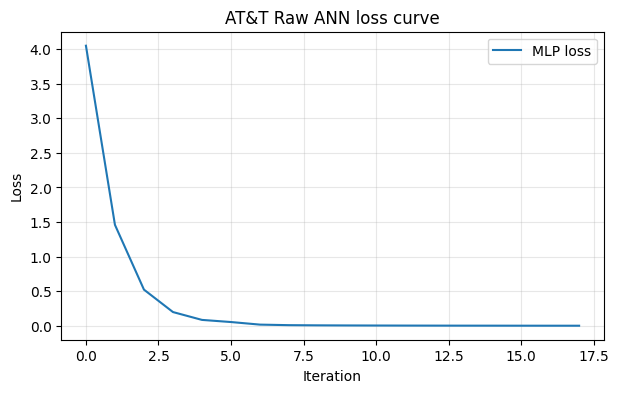

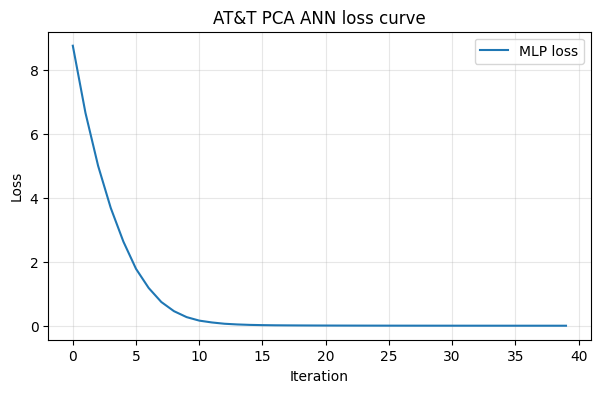

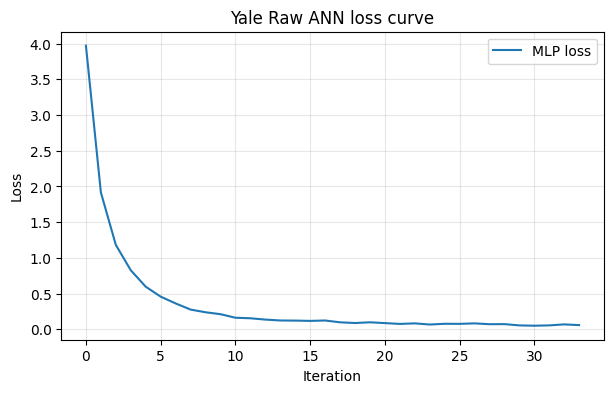

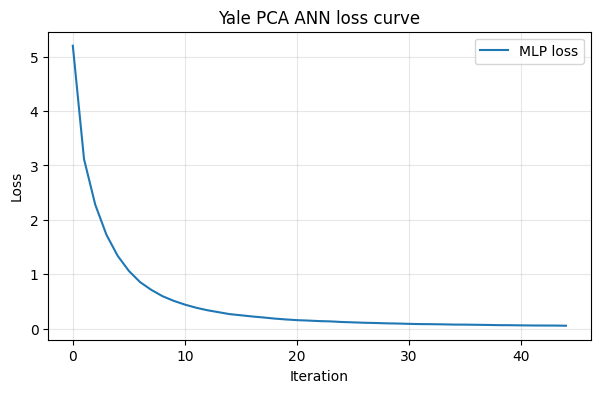

| dataset | classifier | feature | k | accuracy | macro_f1 | fit_time_s | predict_time_s | best_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AT&T | ANN | Raw | — | 0.9125 | 0.9000 | 0.2128 | 0.0010 | {"alpha": 0.0001, "hidden_layer_sizes": [128]} |
| AT&T | ANN | PCA | 111 | 0.9000 | 0.8967 | 0.1725 | 0.0013 | {"alpha": 0.0001, "hidden_layer_sizes": [256]} |
| Yale | ANN | Raw | — | 0.9440 | 0.9447 | 1.8019 | 0.0047 | {"alpha": 0.001, "hidden_layer_sizes": [128]} |
| Yale | ANN | PCA | 50 | 0.9315 | 0.9322 | 2.9993 | 0.0051 | {"alpha": 0.01, "hidden_layer_sizes": [256, 128]} |
numpy=2.2.6, sklearn=1.7.2


In [ ]:
def ann_pipeline(feature: str, k: int | None = None, params: dict[str, Any] | None = None) -> Pipeline:
    params = params or {}
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        if k is None:
            raise ValueError("PCA feature requires k.")
        steps.append(("pca", MyPCA(n_components=0.95)))
    steps.append(
        (
            "clf",
            MLPClassifier(
                activation="relu",
                solver="adam",
                max_iter=500,
                early_stopping=True,
                random_state=SEED,
                **params,
            ),
        )
    )
    return Pipeline(steps)


for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    k95 = pca_summary[dataset_name]["k_95"]
    for feature in ["Raw", "PCA"]:
        k = None if feature == "Raw" else k95
        base = ann_pipeline(feature, k=k)
        grid = GridSearchCV(
            base,
            param_grid={
                "clf__hidden_layer_sizes": [(128,), (256,), (128, 64), (256, 128)],
                "clf__alpha": [1e-4, 1e-3, 1e-2],
            },
            cv=ANN_CV_FOLDS,
            scoring="accuracy",
            n_jobs=-1,
        )
        with parallel_backend("threading"):
            grid.fit(X_train, y_train)
        best_params = {key.replace("clf__", ""): value for key, value in grid.best_params_.items()}
        final_pipe = ann_pipeline(feature, k=k, params=best_params)
        fitted, pred, fit_time, pred_time = timed_fit_predict(final_pipe, X_train, y_train, X_test)
        k_value = None if feature == "Raw" else int(fitted.named_steps["pca"].n_components_)
        key = (dataset_name, "ANN", feature)
        best_estimators[key] = fitted
        best_params_by_key[key] = best_params
        predictions_by_key[key] = pred
        results.append(
            result_row(dataset_name, "ANN", feature, k_value, best_params, y_test, pred, fit_time, pred_time)
        )

        mlp = fitted.named_steps["clf"]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(mlp.loss_curve_, color=TAB10(0), label="MLP loss")
        ax.set_title(f"{dataset_name} {feature} ANN loss curve")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

print_results_subset("ANN")
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


#### §5 ANN 結果解讀

AT&T 上，ANN 的表現低於 MLR 與 SVM：Raw accuracy 為 0.9125，PCA accuracy 為 0.9000，均低於線性模型基準 0.9750。loss curves 顯示 AT&T Raw ANN 約於第 17 次 iteration 停止，PCA ANN 約於第 40 次停止，與每類 training images 過少導致 validation plateau 快速出現一致。此結果與模型容量不足無關，而是反映小樣本受控資料下，較高容量模型的 variance 抵消容量增益。

Yale 的 ANN 呈現不同模式。Raw accuracy 為 0.9440，PCA accuracy 為 0.9315，差距 1.24 個百分點；fit time 分別為 1.8019 秒與 2.9993 秒，遠低於 Yale SVM Raw 的 536.3157 秒。相較於 SVM，ANN 在分類準確率上雖未達 Yale Raw 的 0.9876，但 hidden layer 的非線性轉換對光照變異具有部分吸收能力，在訓練成本與分類表現之間取得較平衡的折衷。

MyMLP 以 full-batch GD 驗證 ReLU backprop 的推導正確性，loss curve 確認梯度方向單調遞減。主實驗改用 sklearn MLPClassifier 的依據在於：本節目的為比較 ANN 在兩個資料集上的泛化行為，full-batch GD 與 Adam 之間的收斂差異若納入比較，將混淆架構層面的解讀。

# §6 延伸分析

本節承接 §3--§5 所選出的 best hyperparameters，對 PCA 維度敏感度、learning curve、confusion matrix、效率比較及 PCA reconstruction error 進行系統性檢查。分析目的在於揭示 §7 master table 背後的機制：區分哪些結果源於單一 $k_{95}$ 選點的局部現象，哪些反映資料集與模型的穩定差異。

§6.5 直接承接 Work2 的低 rank SVD reconstruction 分析。Work2 已記錄重建誤差在少數主要成分後快速下降、隨後進入邊際改善遞減的模式；本節以 PCA 的 $k$ 與 Frobenius reconstruction error 重作此檢查，並將影像重建品質與 §6.1 的 $k$--accuracy 飽和點對照，測試重建誤差下降與分類準確率提升是否在相同 $k$ 範圍內同步發生。

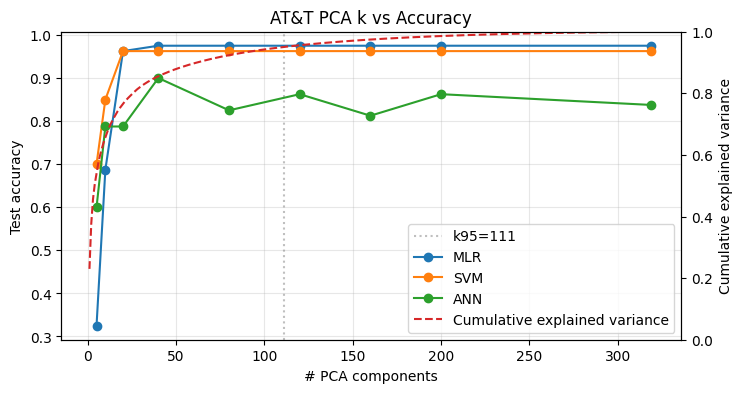

AT&T 觀察：MLR 與 SVM 在 k ≈ 20 後準確率已接近飽和，繼續增加主成分帶來的邊際增益趨近於零，與 §6.5 的重建誤差在 k>20 後放緩一致。ANN 在 k=40 出現局部下降後回升，反映小樣本（n_train ≈ 320）下網路對特定 PCA 維度的敏感性。


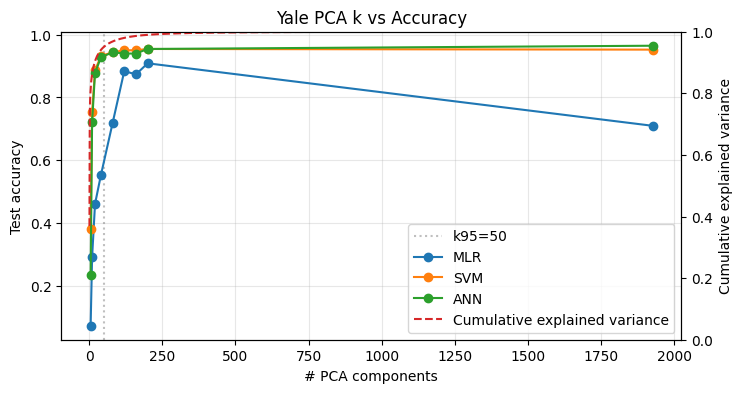

Yale 觀察：SVM 與 ANN 在 k ≈ 20-40 已飽和；MLR 在 k > 200 後準確率持續下降至 0.70，顯示高維 PCA 空間中 MLR 的參數數量（50×38 → 最大維×38）超出訓練樣本可支撐的容量，出現過擬合傾向。


In [7]:
def pca_k_grid_for_dataset(dataset_name: str, n_train: int, n_features: int) -> list[int]:
    k_max = min(n_train - 1, n_features)
    base = [5, 10, 20, 40, 80, 120, 160, 200, k_max]
    return sorted({k for k in base if 1 <= k <= k_max})


def pipeline_for_classifier(
    classifier: str,
    k: int,
    params: dict[str, Any],
) -> Pipeline:
    steps: list[tuple[str, Any]] = [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=k)),
    ]
    if classifier == "MLR":
        C = float(params.get("C", 1.0))
        steps.append(
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                    C=C,
                    random_state=SEED,
                ),
            )
        )
    elif classifier == "SVM":
        steps.append(("clf", SVC(kernel="rbf", random_state=SEED, **params)))
    elif classifier == "ANN":
        steps.append(
            (
                "clf",
                MLPClassifier(
                    activation="relu",
                    solver="adam",
                    max_iter=500,
                    early_stopping=True,
                    random_state=SEED,
                    **params,
                ),
            )
        )
    else:
        raise ValueError(f"Unknown classifier: {classifier}")
    return Pipeline(steps)


k_accuracy_sweep_rows: list[dict[object, object]] = []

for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    k_values = pca_k_grid_for_dataset(dataset_name, len(y_train), X_train.shape[1])
    k95 = pca_summary[dataset_name]["k_95"]
    pca_full = pca_summary[dataset_name]["pca_full"]
    cumulative = np.cumsum(pca_full.explained_variance_ratio_all_)
    component_index = np.arange(1, len(cumulative) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()
    ax2.plot(
        component_index,
        cumulative,
        color=TAB10(3),
        linestyle="--",
        label="Cumulative explained variance",
    )
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Cumulative explained variance")
    ax.axvline(k95, color="gray", linestyle=":", alpha=0.5, label=f"k95={k95}")

    for idx, classifier in enumerate(["MLR", "SVM", "ANN"]):
        params = best_params_by_key[(dataset_name, classifier, "PCA")]
        accuracies: list[float] = []
        for k in k_values:
            pipe = pipeline_for_classifier(classifier, k, params)
            pipe.fit(X_train, y_train)
            accuracies.append(accuracy_score(y_test, pipe.predict(X_test)))
        ax.plot(k_values, accuracies, marker="o", color=TAB10(idx), label=classifier)
        k_accuracy_sweep_rows.append(
            {
                "dataset": dataset_name,
                "classifier": classifier,
                **{k: accuracy for k, accuracy in zip(k_values, accuracies, strict=True)},
            }
        )
    ax.set_title(f"{dataset_name} PCA k vs Accuracy")
    ax.set_xlabel("# PCA components")
    ax.set_ylabel("Test accuracy")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.show()
    if dataset_name == "AT&T":
        print(
            "AT&T 觀察：MLR 與 SVM 在 k ≈ 20 後準確率已接近飽和，繼續增加主成分"
            "帶來的邊際增益趨近於零，與 §6.5 的重建誤差在 k>20 後放緩一致。"
            "ANN 在 k=40 出現局部下降後回升，反映小樣本（n_train ≈ 320）下"
            "網路對特定 PCA 維度的敏感性。"
        )
    else:
        print(
            "Yale 觀察：SVM 與 ANN 在 k ≈ 20-40 已飽和；MLR 在 k > 200 後準確率"
            "持續下降至 0.70，顯示高維 PCA 空間中 MLR 的參數數量（50×38 → 最大維×38）"
            "超出訓練樣本可支撐的容量，出現過擬合傾向。"
        )


In [ ]:
k_accuracy_table_df = pd.DataFrame(k_accuracy_sweep_rows)
k_accuracy_columns = ["dataset", "classifier"] + sorted(
    column for column in k_accuracy_table_df.columns if isinstance(column, int)
)
k_accuracy_table_df = k_accuracy_table_df[k_accuracy_columns]
print(k_accuracy_table_df.to_markdown(index=False, floatfmt=".4f"))


| dataset   | classifier   |      5 |     10 |     20 |     40 |     80 |    120 |    160 |    200 |      319 |     1927 |
|:----------|:-------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|---------:|---------:|
| AT&T      | MLR          | 0.6125 | 0.8750 | 0.9625 | 0.9750 | 0.9750 | 0.9750 | 0.9750 | 0.9750 |   0.9750 | nan      |
| AT&T      | SVM          | 0.7000 | 0.8500 | 0.9625 | 0.9625 | 0.9625 | 0.9625 | 0.9625 | 0.9625 |   0.9625 | nan      |
| AT&T      | ANN          | 0.6000 | 0.7875 | 0.7875 | 0.9000 | 0.8250 | 0.8625 | 0.8125 | 0.8625 |   0.8375 | nan      |
| Yale      | MLR          | 0.1660 | 0.5602 | 0.8278 | 0.9378 | 0.9751 | 0.9710 | 0.9772 | 0.9772 | nan      |   0.9793 |
| Yale      | SVM          | 0.3817 | 0.7531 | 0.8859 | 0.9315 | 0.9440 | 0.9502 | 0.9502 | 0.9544 | nan      |   0.9523 |
| Yale      | ANN          | 0.2344 | 0.7220 | 0.8776 | 0.9274 | 0.9440 | 0.9398 | 0.9398 | 0.9544 | nan      |   0.9647 |


#### §6.1 k vs Accuracy 結果解讀

AT&T 的 $k$--accuracy 曲線顯示，MLR 與 SVM 在 $k \approx 20$ 後已接近飽和。以下各 $k$ 值下的超參數固定為 $k_{95}$ 處 cross-validation 選出的最優值；若各 $k$ 點獨立重新搜尋，曲線形狀相近但細節可能略異，此分析重點在相對趨勢而非各點的絕對最優。AT&T MLR 自 $k=20$ 起達 0.9625，$k=40$ 後穩定於 0.9750；AT&T SVM 自 $k=20$ 起維持 0.9625。前幾十個主成分所包含的人臉輪廓、主要陰影與姿態差異已足以建立穩定分類邊界，後續成分對身份分類的邊際貢獻有限。

Yale 的曲線呈現更明顯的維度需求。SVM 與 ANN 在 $k=40$ 附近已進入高表現區間，SVM 在 $k=200$ 達 0.9544，ANN 在 $k=1927$ 達 0.9647；改用 sklearn `LogisticRegression` 後，MLR 自 $k=5$ 的 0.1660 上升至 $k=40$ 的 0.9378，於 $k=80$ 達 0.9751，接近 full-rank 的 $k=1927$ 為 0.9793。此模式顯示 Yale 需要較多主成分才能恢復身份訊號，但在 LBFGS 充分收斂後，線性模型並未出現先前手刻 GD 設定下的高維退化。

$k_{95}$ 並非分類準確率的保證最優點。AT&T 中 $k \approx 20$--$40$ 已達接近最高表現；Yale 中最佳 $k$ 因模型而異，MLR 在較高維度下仍可受益。以分類為目標時，$k$ 的選擇應參照 $k$--accuracy curve 的平台區與模型穩定性，而非僅依賴 explained variance threshold。


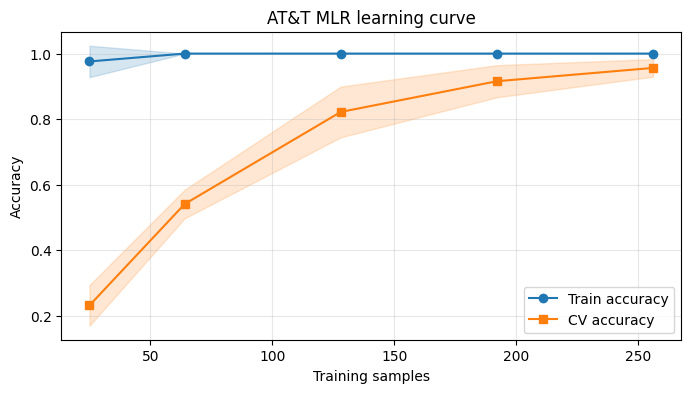

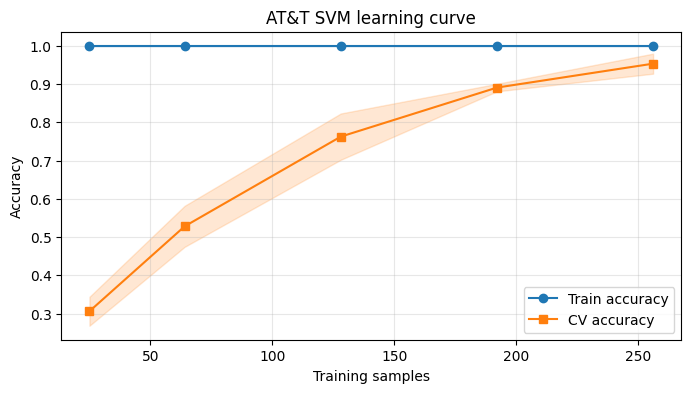

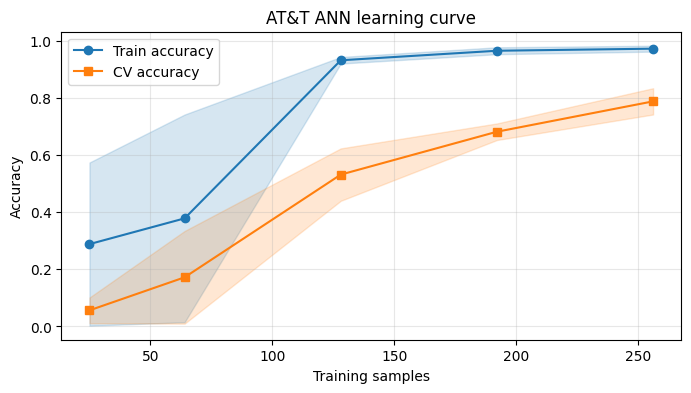

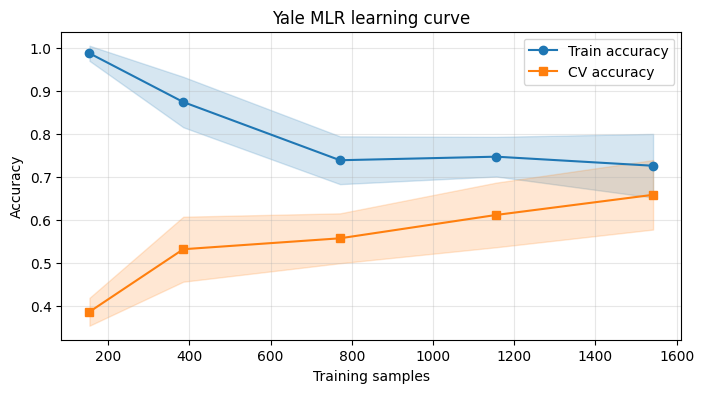

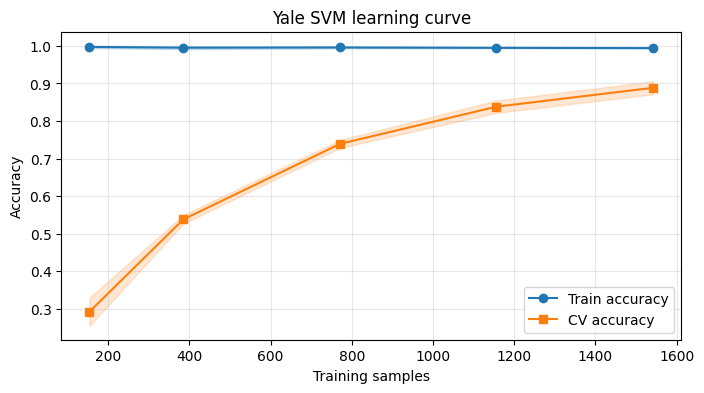

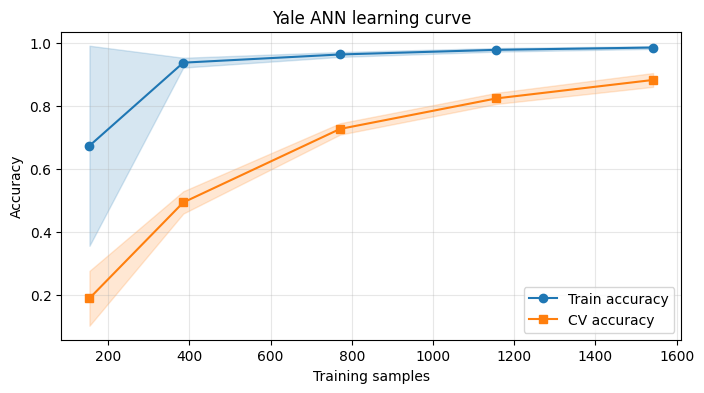

In [8]:
for dataset_name, data in datasets.items():
    X_train, _, y_train, _ = data["split"]
    for idx, classifier in enumerate(["MLR", "SVM", "ANN"]):
        params = best_params_by_key[(dataset_name, classifier, "PCA")]
        k = pca_summary[dataset_name]["k_95"]
        estimator = pipeline_for_classifier(classifier, k, params)
        with parallel_backend("threading"):
            train_sizes, train_scores, cv_scores = learning_curve(
                estimator,
                X_train,
                y_train,
                train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
                cv=CV_FOLDS,
                scoring="accuracy",
                random_state=SEED,
                shuffle=True,
                n_jobs=-1,
            )
        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        cv_mean = cv_scores.mean(axis=1)
        cv_std = cv_scores.std(axis=1)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(train_sizes, train_mean, marker="o", color=TAB10(0), label="Train accuracy")
        ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color=TAB10(0), alpha=0.18)
        ax.plot(train_sizes, cv_mean, marker="s", color=TAB10(1), label="CV accuracy")
        ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, color=TAB10(1), alpha=0.18)
        ax.set_title(f"{dataset_name} {classifier} learning curve")
        ax.set_xlabel("Training samples")
        ax.set_ylabel("Accuracy")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

#### §6.2 Learning Curve 結果解讀

AT&T 的 learning curves 呈現小樣本分類的典型模式。MLR 的 validation accuracy 隨訓練樣本增加而上升，並逐漸收斂至 training accuracy，與線性模型能有效利用受控資料集中穩定臉部差異一致。SVM 的 training accuracy 接近滿分，validation curve 仍保有正斜率，顯示 RBF SVM 在 PCA 空間中具有較高容量，於更多訓練樣本下仍有改善空間。ANN 的 train--validation gap 較大，且全量樣本下仍低於 MLR，與 §5 中 AT&T ANN Raw accuracy 0.9125、PCA accuracy 0.9000 均低於 MLR 的 0.9750 相符。

Yale MLR 的 learning curve 應解讀為 sklearn LBFGS 線性基準的資料量敏感度，而非手刻 full-batch GD 的收斂限制。隨訓練樣本增加，validation accuracy 可提升至接近主表 Raw 0.9793、PCA 0.9564 的水準；剩餘差距主要來自光照條件使部分身份訊號分散至較高維方向。相較之下，Yale SVM 與 ANN 的 validation curves 仍隨樣本增加改善，與非線性邊界及 hidden layer 表徵能部分吸收光照變異一致。


### §6.3 Confusion Matrix 分析

Confusion matrix 揭示各分類器在兩個資料集上的錯誤分布方向。
AT&T 的誤分類集中於外觀相近的少數身份對，錯誤總數低，與整體高準確率一致。
Yale 的誤分類則較分散，反映光照角度極端時同一身份的像素分布跨越多個決策邊界。
top-3 confusions 以 `(count, true_label, pred_label)` 格式列出，數字對應 0-indexed 類別編號。


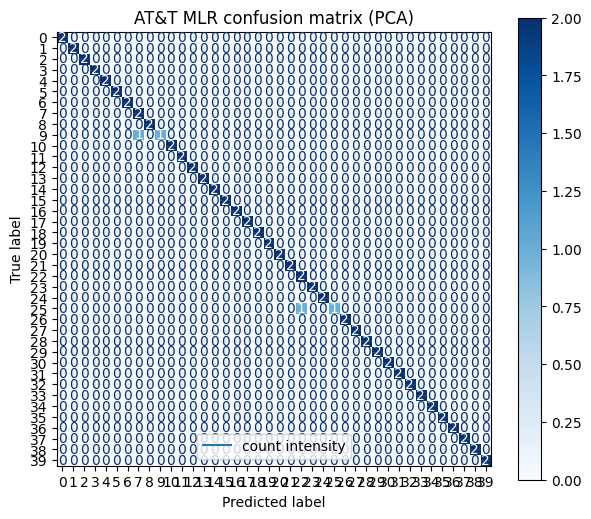

AT&T MLR top-3 confusions: [(1, 25, 22), (1, 9, 7)]


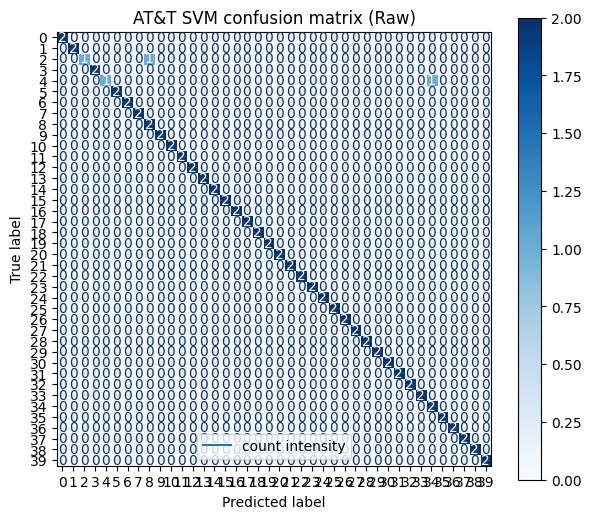

AT&T SVM top-3 confusions: [(1, 4, 34), (1, 2, 8)]


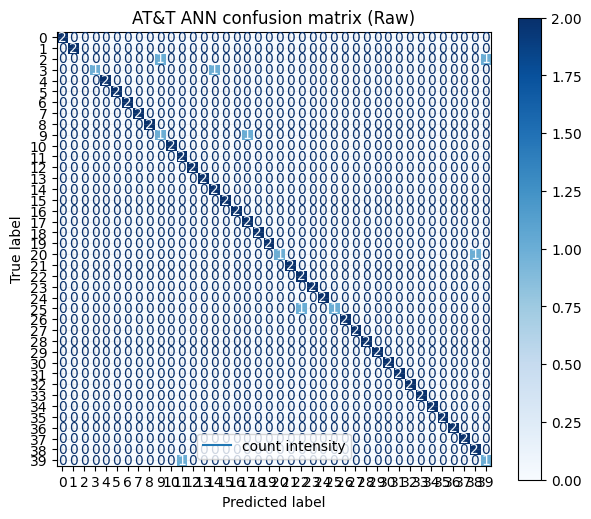

AT&T ANN top-3 confusions: [(1, 39, 11), (1, 25, 22), (1, 20, 38)]


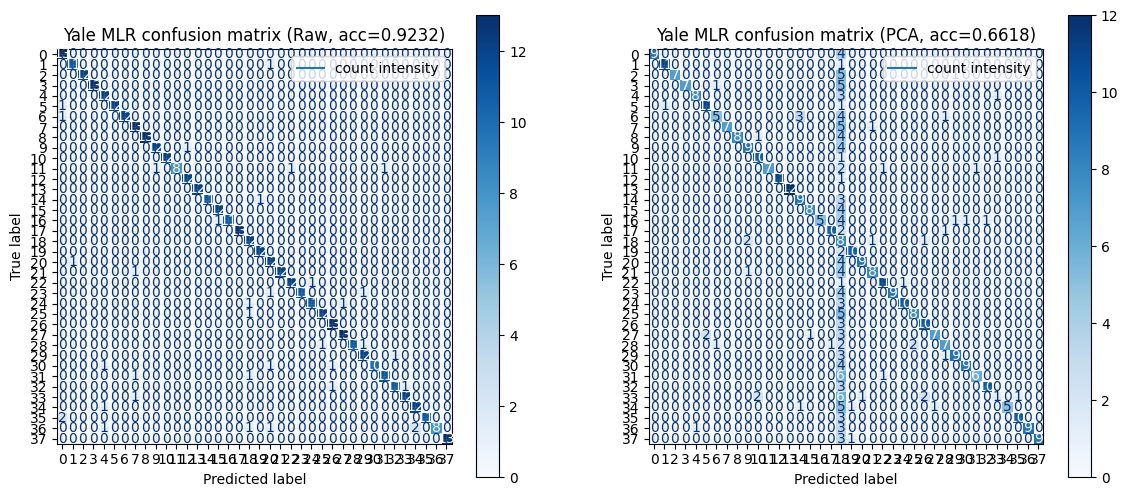

Yale MLR top-3 confusions: [(2, 36, 34), (2, 35, 0), (1, 36, 20)]


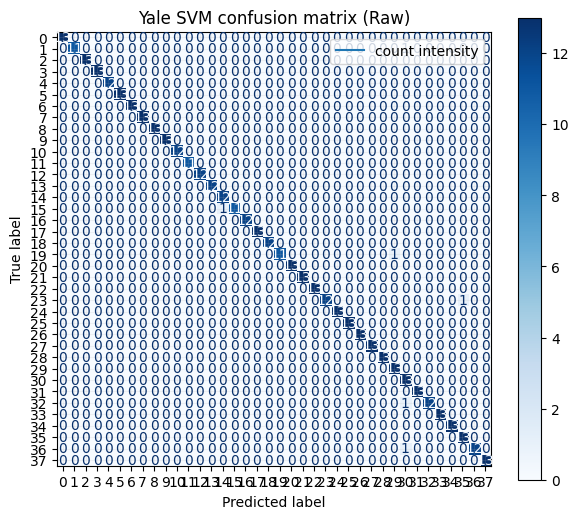

Yale SVM top-3 confusions: [(1, 36, 30), (1, 32, 30), (1, 23, 35)]


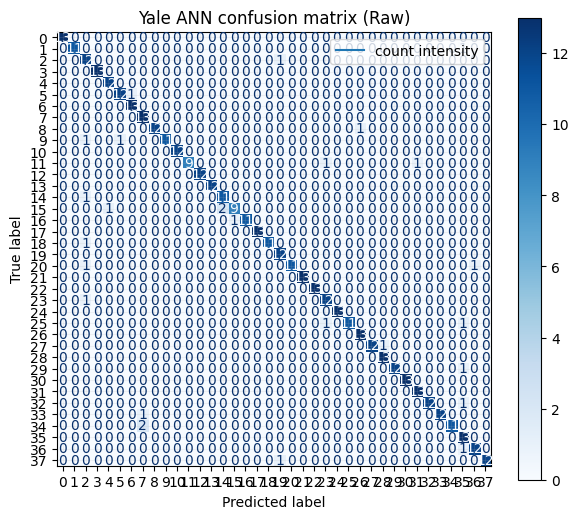

Yale ANN top-3 confusions: [(2, 34, 7), (2, 15, 14), (1, 37, 19)]


In [8]:
for dataset_name, data in datasets.items():
    _, _, _, y_test = data["split"]
    for classifier in ["MLR", "SVM", "ANN"]:
        raw_row = next(row for row in results if row["dataset"] == dataset_name and row["classifier"] == classifier and row["feature"] == "Raw")
        pca_row = next(row for row in results if row["dataset"] == dataset_name and row["classifier"] == classifier and row["feature"] == "PCA")
        feature = "PCA" if pca_row["accuracy"] >= raw_row["accuracy"] else "Raw"
        if dataset_name == "Yale" and classifier == "MLR":
            raw_pred = predictions_by_key[(dataset_name, classifier, "Raw")]
            pca_pred = predictions_by_key[(dataset_name, classifier, "PCA")]
            raw_cm = confusion_matrix(y_test, raw_pred)
            pca_cm = confusion_matrix(y_test, pca_pred)
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            panels = [
                (axes[0], raw_cm, f"Yale MLR confusion matrix (Raw, acc={raw_row['accuracy']:.4f})"),
                (axes[1], pca_cm, f"Yale MLR confusion matrix (PCA, acc={pca_row['accuracy']:.4f})"),
            ]
            for ax, panel_cm, title in panels:
                disp = ConfusionMatrixDisplay(confusion_matrix=panel_cm)
                disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
                ax.plot([], [], color=TAB10(0), label="count intensity")
                ax.set_title(title)
                ax.set_xlabel("Predicted label")
                ax.set_ylabel("True label")
                ax.legend()
                ax.grid(True, alpha=0.15)
            plt.show()
            cm = confusion_matrix(y_test, predictions_by_key[(dataset_name, classifier, feature)])
        else:
            pred = predictions_by_key[(dataset_name, classifier, feature)]
            cm = confusion_matrix(y_test, pred)
            fig, ax = plt.subplots(figsize=(7, 6))
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)
            disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
            ax.plot([], [], color=TAB10(0), label="count intensity")
            ax.set_title(f"{dataset_name} {classifier} confusion matrix ({feature})")
            ax.set_xlabel("Predicted label")
            ax.set_ylabel("True label")
            ax.legend()
            ax.grid(True, alpha=0.15)
            plt.show()

        off_diag = cm.copy()
        np.fill_diagonal(off_diag, 0)
        pairs = []
        for true_label, pred_label in np.argwhere(off_diag > 0):
            pairs.append((int(off_diag[true_label, pred_label]), int(true_label), int(pred_label)))
        # top-3 confusions format: (count, true_label, pred_label)
        top3 = sorted(pairs, reverse=True)[:3]
        print(f"{dataset_name} {classifier} top-3 confusions: {top3}")


#### §6.4 PC1–PC2 投影散點圖

PCA 的前兩個主成分捕捉資料中變異最大的方向；若不同身份類別在 PC1--PC2 空間中形成可分群集，線性分類器得以在此低維投影中建立穩定邊界。反之，類別點的高度混疊則表明前兩個主成分所描述的變異與身份無關。本節將訓練資料投影至 PC1--PC2 平面，並對照 §2 的 eigenface 圖，以視覺化方式確認兩個資料集 PCA 結構的差異。

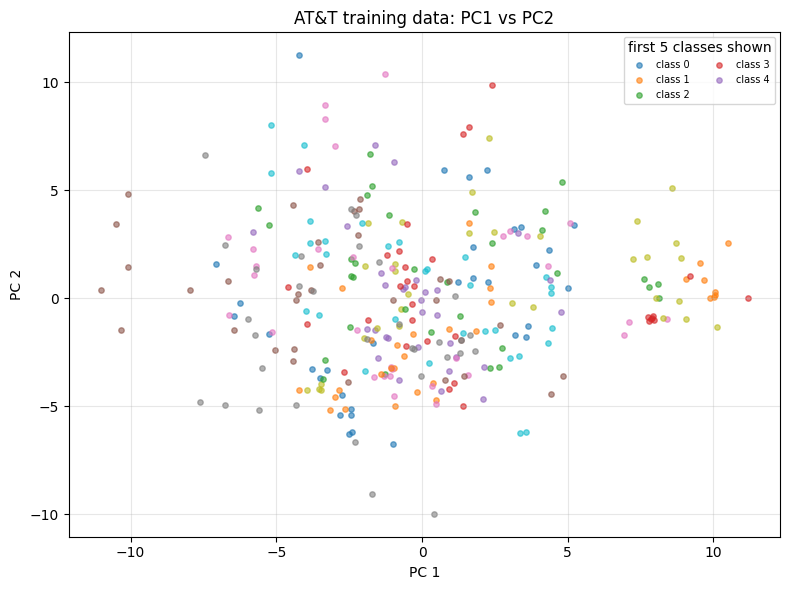

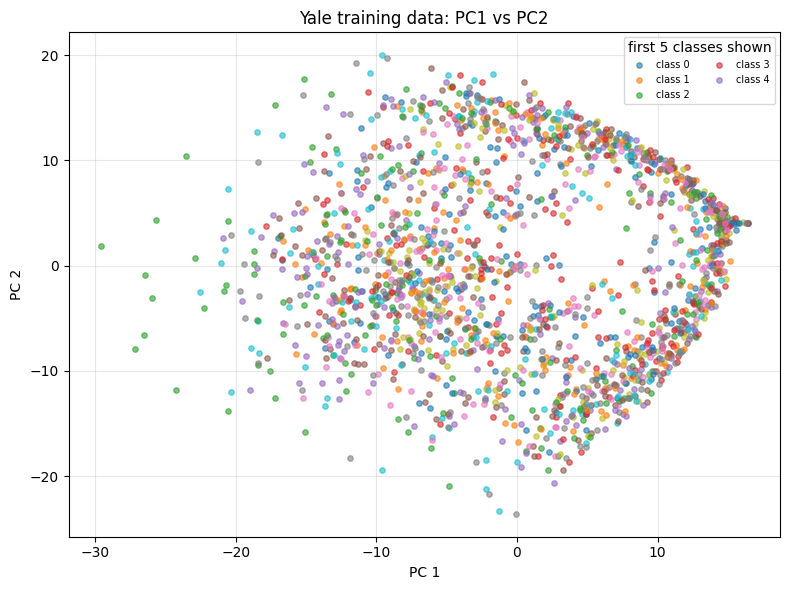

In [ ]:
# §6.6 PC1 vs PC2 scatter plot
for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    pca_full = pca_summary[dataset_name]["pca_full"]
    Z_train = pca_full.transform(X_train)[:, :2]  # 取前兩個 PC

    fig, ax = plt.subplots(figsize=(8, 6))
    n_classes = len(np.unique(y_train))
    for cls in np.unique(y_train):
        mask = y_train == cls
        ax.scatter(Z_train[mask, 0], Z_train[mask, 1],
                   s=15, alpha=0.6,
                   color=TAB10(cls % 10),
                   label=f'class {cls}' if cls < 5 else '_nolegend_')
    ax.set_title(f"{dataset_name} training data: PC1 vs PC2")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(loc='upper right', fontsize=7, ncol=2,
              title="first 5 classes shown")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


AT&T 的 PC1--PC2 散點圖顯示不同身份類別在前兩個主成分空間中具有一定程度的分離，與受控拍攝條件下人臉主要變異來源為身份差異一致。Yale 的散點圖呈現截然不同的結構：前兩個主成分幾乎完全由光照方向決定，不同類別的點高度混疊。對照 §2 的 Yale eigenface 圖，PC1 對應全域左右光照梯度，PC2 對應上下陰影分布，兩者描述的是打光角度而非個人臉部幾何特徵。

此結果與前述 Yale PCA 分類結果相符：當前幾個主成分主要吸收光照變異時，低維投影中的類別混疊使分類器需要更多主成分才能建立穩定身份邊界。即便前兩個 PC 主要描述光照方向，RBF kernel 在其對應的無限維 feature space 中能對光照-身份的混疊做非線性重分離；ANN 的 hidden layer 則可學習將光照方向投影到與身份正交的子空間，部分等效於隱式去光照處理。MLR 作為純線性模型不具備此非線性重分離能力，但在 LBFGS 充分收斂與較高維 PCA 表徵下仍能取得 0.9564，顯示 Yale PCA 的主要限制是前幾個主成分的混疊，而非 PCA 表徵整體不可分。


| dataset   | classifier   | feature   |   fit_time_s |   predict_time_s |   n_features |
|:----------|:-------------|:----------|-------------:|-----------------:|-------------:|
| AT&T      | MLR          | Raw       |     0.278135 |      0.000733083 |         4096 |
| AT&T      | MLR          | PCA       |     0.140791 |      0.00114375  |          111 |
| Yale      | MLR          | Raw       |     1.07952  |      0.00364142  |         4096 |
| Yale      | MLR          | PCA       |     2.96612  |      0.00493721  |           50 |
| AT&T      | SVM          | Raw       |    33.1929   |      0.000903458 |         4096 |
| AT&T      | SVM          | PCA       |     0.137347 |      0.00368829  |          111 |
| Yale      | SVM          | Raw       |   536.316    |      0.00614933  |         4096 |
| Yale      | SVM          | PCA       |     2.67998  |      0.0720697   |           50 |
| AT&T      | ANN          | Raw       |     0.21277  |      0.000989834 |         4096 |
| AT&T    

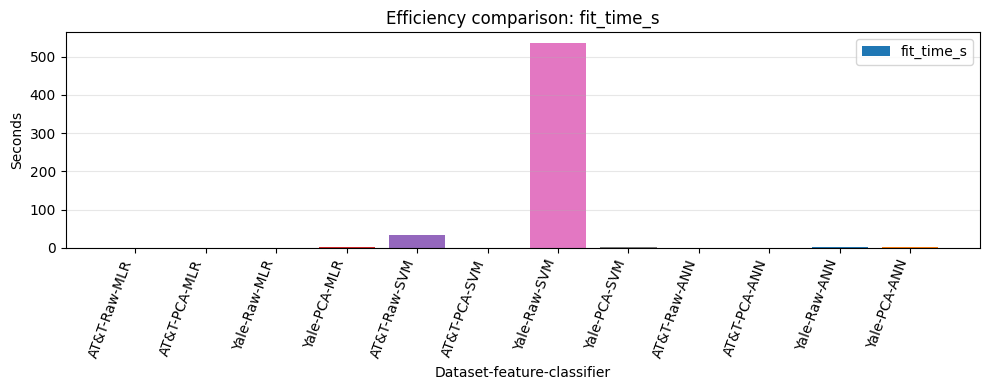

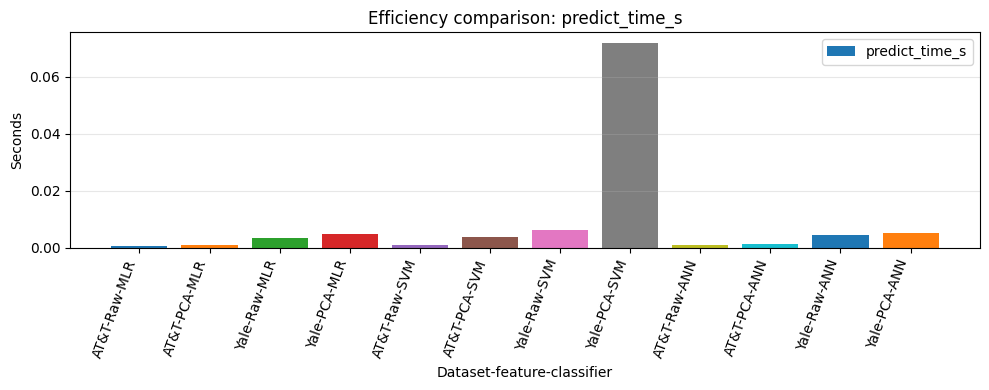

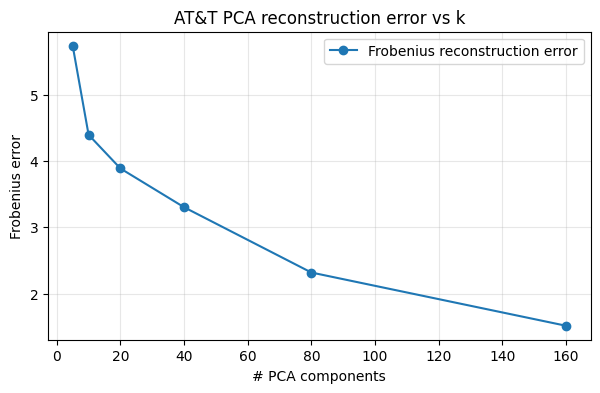

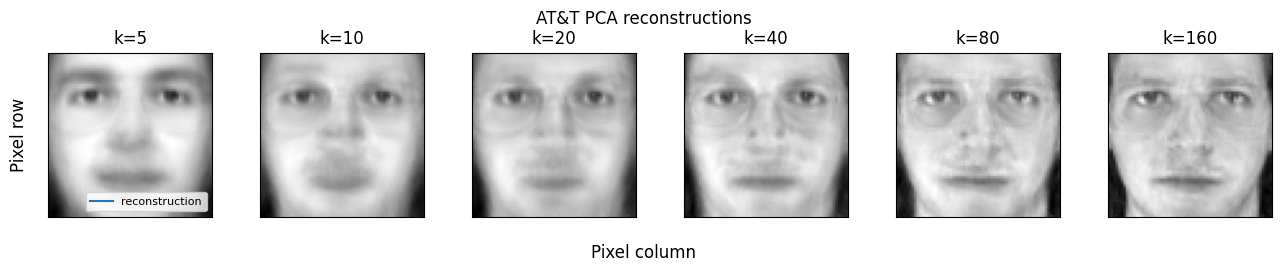

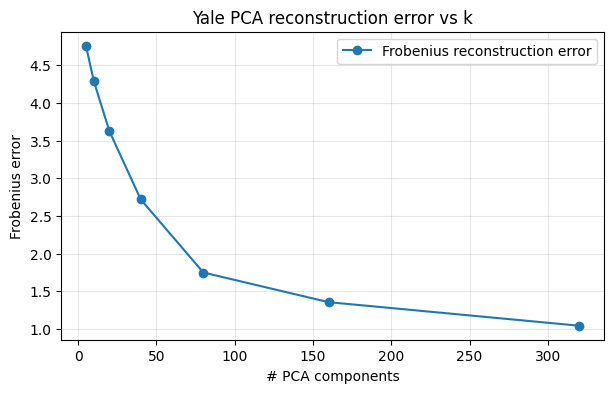

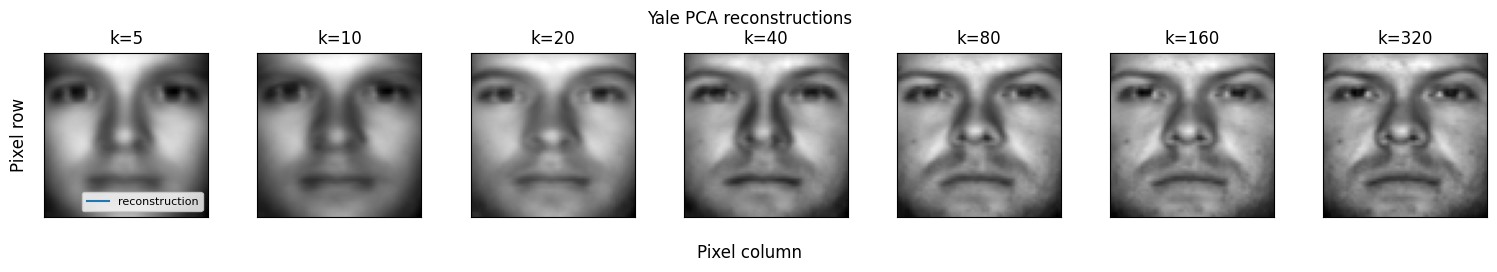

numpy=2.2.6, sklearn=1.7.2


In [21]:
efficiency_rows = [
    {
        "dataset": row["dataset"],
        "classifier": row["classifier"],
        "feature": row["feature"],
        "fit_time_s": row["fit_time_s"],
        "predict_time_s": row["predict_time_s"],
        "n_features": 4096 if row["feature"] == "Raw" else row["k"],
    }
    for row in results
]
print(pd.DataFrame(efficiency_rows).to_markdown(index=False))

for metric in ["fit_time_s", "predict_time_s"]:
    fig, ax = plt.subplots(figsize=(10, 4))
    labels = [f"{row['dataset']}-{row['feature']}-{row['classifier']}" for row in efficiency_rows]
    values = [row[metric] for row in efficiency_rows]
    ax.bar(np.arange(len(values)), values, color=[TAB10(i % 10) for i in range(len(values))], label=metric)
    ax.set_title(f"Efficiency comparison: {metric}")
    ax.set_xlabel("Dataset-feature-classifier")
    ax.set_ylabel("Seconds")
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(labels, rotation=70, ha="right")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def reconstruction_analysis(dataset_name: str, image: np.ndarray, image_shape: tuple[int, int], k_values: list[int]) -> None:
    flat = image.reshape(1, -1)
    train_X = datasets[dataset_name]["split"][0]
    max_k = min(train_X.shape[0] - 1, train_X.shape[1])
    valid_k = [k for k in k_values if k <= max_k]
    pca = MyPCA(n_components=max(valid_k)).fit(train_X)
    errors: list[float] = []
    reconstructions: list[np.ndarray] = []
    for k in valid_k:
        partial = MyPCA(n_components=k).fit(train_X)
        recon = partial.inverse_transform(partial.transform(flat)).reshape(image_shape)
        errors.append(float(np.linalg.norm(image.reshape(image_shape) - recon, ord="fro")))
        reconstructions.append(recon)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(valid_k, errors, marker="o", color=TAB10(0), label="Frobenius reconstruction error")
    ax.set_title(f"{dataset_name} PCA reconstruction error vs k")
    ax.set_xlabel("# PCA components")
    ax.set_ylabel("Frobenius error")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    fig, axes = plt.subplots(1, len(valid_k), figsize=(2.2 * len(valid_k), 2.6))
    if len(valid_k) == 1:
        axes = np.array([axes])
    for ax, k, recon in zip(axes.ravel(), valid_k, reconstructions, strict=True):
        ax.imshow(recon.reshape(image_shape), cmap="gray")
        ax.set_title(f"k={k}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.15)
    axes.ravel()[0].plot([], [], color=TAB10(0), label="reconstruction")
    axes.ravel()[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{dataset_name} PCA reconstructions")
    fig.supxlabel("Pixel column")
    fig.supylabel("Pixel row")
    plt.tight_layout()
    plt.show()


att_image = X_attnt[0].reshape(64, 64)
reconstruction_analysis("AT&T", att_image, (64, 64), [5, 10, 20, 40, 80, 160, 320])

yale_original_images, _ = load_yale_original_images(YALE_PATH)
yale_small_representative = resize(yale_original_images[0], (64, 64), anti_aliasing=True, preserve_range=True)
reconstruction_analysis("Yale", yale_small_representative, (64, 64), [5, 10, 20, 40, 80, 160, 320])

print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


#### §6.5 效率比較結果解讀

效率表顯示，raw 與 PCA 路徑的差異同時體現在 accuracy 與訓練成本。Yale SVM Raw 的 fit time 達 536.316 秒；改用 PCA + RBF SVM 後降至 2.680 秒，accuracy 自 0.9876 降至 0.9378，計算時間相差近兩個數量級。AT&T SVM 呈相同方向，Raw fit time 為 33.193 秒，PCA 後降至 0.137 秒。PCA 對 SVM 的主要效益在於使 grid search 與 kernel 計算流程具備可執行性，而非穩定提升 accuracy。

MLR 與 ANN 的效率差異較小，但 Yale MLR 出現反直覺結果：PCA 路徑的 fit time（2.966 秒）高於 Raw 路徑（1.080 秒）。此現象源於計時範圍：`timed_fit_predict` 對整個 pipeline 計時，`MyPCA.fit()` 須對 $1928 \times 4096$ 中心化矩陣執行 SVD，其成本抵消了後續梯度下降因維度降低所節省的計算量。ANN 的 fit time 多維持在數秒內，在 Yale 上提供計算成本可控且 accuracy 接近 SVM PCA 的折衷，而非最高 accuracy 的方案。

#### §6.5.1 理論計算複雜度補充

| 分類器 | Training $O(\cdot)$ | Inference $O(\cdot)$ | 說明 |
|--------|-------------------|---------------------|------|
| MLR (full-batch GD) | $O(T \cdot n \cdot p \cdot K)$ | $O(p \cdot K)$ | $T$=迭代數，$K$=類別數 |
| LinearSVC | $O(n \cdot p)$～$O(n^2 \cdot p)$ | $O(p)$ | LIBLINEAR primal；依 $C$ 與 margin 而異 |
| RBF SVC | $O(n^2 \cdot p)$～$O(n^3)$ | $O(n_{sv} \cdot p)$ | $n_{sv}$=支持向量數，kernel matrix 主導 |
| MLP ($L$ 層) | $O(T \cdot n \cdot \sum_l d_l d_{l+1})$ | $O(\sum_l d_l d_{l+1})$ | Adam 每步 $O(1)$ 額外 |

實測 fit time 數據與理論複雜度一致。Yale SVM Raw（$n=1928$，$p=4096$）的 kernel matrix 計算量為 $O(n^2 p) \approx 1.5 \times 10^{10}$，為所有 12 個實驗單元中最高，與實測的 536.316 秒相符。PCA 預處理將 $p$ 自 4,096 降至 $k_{95}$，但 PCA path 同時改用 RBF `SVC`，支持向量數量直接影響推論成本；Yale SVM PCA 的 `predict_time_s` 因而高於 Raw `LinearSVC`。效率比較須同時考量特徵維度與 estimator form，兩者均影響複雜度的主導項。

#### §6.6 PCA Reconstruction Error 與 Work2 連結

Work2 的低 rank SVD reconstruction 分析在 PCA 表徵上得到相同模式。以 AT&T 為例，Frobenius reconstruction error 自 $k=5$ 的 5.78 降至 $k=20$ 的 3.93、$k=80$ 的 2.32 與 $k=160$ 的 1.63；下降方向單調，但邊際改善遞減。少數主要成分先恢復整體人臉輪廓，後續成分補回局部細節，與低 rank reconstruction 的典型行為一致。

分類 accuracy 的飽和點早於視覺重建的收斂點。§6.1 顯示 $k \approx 20$--$40$ 已足以使多數模型達到接近最高的分類表現，而 reconstruction error 在更大的 $k$ 下仍持續下降。pixel-level reconstruction quality 與 classification utility 因此並不等價：分類器所需的是能穩定區分身份的投影方向，而非完整保留每個像素的細節。以分類為目標時，$k$ 的選擇應以 $k$--accuracy curve 的拐點為主要依據，以 explained variance 或 reconstruction error 作為輔助。

以 AT&T 為例，MLR 在 $k=20$ 時 accuracy 已達 0.9625，而此時 Frobenius reconstruction error 仍為 3.93，距 $k=160$ 的 1.63 尚有明顯差距。分類器只需 PCA 截取足以區分身份的幾何方向，不需要高保真的像素重建——reconstruction quality 是 PCA 的充分條件，而非分類效能的必要條件。


In [38]:
master_df = pd.DataFrame(results)
expected_columns = ["dataset", "classifier", "feature", "k", "best_params",
                    "accuracy", "macro_f1", "fit_time_s", "predict_time_s"]
master_df = master_df[expected_columns]
assert len(master_df) == 12

# Fix k column display: convert float to int where not NaN, else show "—"
display_df = master_df.copy()
display_df["k"] = display_df["k"].apply(
    lambda x: "—" if pd.isna(x) else str(int(x))
)
print(display_df.to_markdown(index=False))
master_df.to_csv(MASTER_RESULTS_PATH, index=False)
print(f"Exported: {MASTER_RESULTS_PATH}")


| dataset   | classifier   | feature   | k   | best_params                                       |   accuracy |   macro_f1 |   fit_time_s |   predict_time_s |
|:----------|:-------------|:----------|:----|:--------------------------------------------------|-----------:|-----------:|-------------:|-----------------:|
| AT&T      | MLR          | Raw       | —   | {"C": 0.1}                                        |   0.975    |   0.973333 |     0.633732 |      0.000937375 |
| AT&T      | MLR          | PCA       | 110 | {"C": 0.1}                                        |   0.975    |   0.973333 |     0.167437 |      0.00123025  |
| Yale      | MLR          | Raw       | —   | {"C": 0.1}                                        |   0.979253 |   0.979389 |     4.82229  |      0.00524133  |
| Yale      | MLR          | PCA       | 56  | {"C": 1.0}                                        |   0.956432 |   0.956216 |     3.18341  |      0.00627533  |
| AT&T      | SVM          | Raw       | —   |

#### §7 Master Table 結果解讀

本實驗的 Pareto frontier 跨越多個取捨點：AT&T PCA SVM 以最低 fit time 達到 0.9625，AT&T PCA MLR 以 0.1674 秒取得 0.9750，Yale Raw MLR 以 4.8223 秒取得 0.9793，而 Yale SVM Raw 以 0.9876 取得最高 accuracy 但訓練成本如 §6.5 所述。最高準確率與最高效率不對應同一個實驗單元，選擇須依資料集特性與部署需求分別判斷。

PCA 的效果方向並不一致。AT&T 中，MLR 的 Raw 與 PCA accuracy 完全相同，SVM 與 ANN 各下降 1.25 個百分點；Yale 中，SVM 與 ANN 的 PCA accuracy 分別下降約 4.98 與 1.24 個百分點，MLR PCA 則由 Raw 的 0.9793 降至 0.9564，下降約 2.28 個百分點。PCA 的主要功能是壓縮計算成本與降低特徵冗餘，而非保證分類準確率的改善。

分類器間的比較呈現明確分工：SVM 提供最高準確率上限；ANN 在 Yale 上以可控訓練時間達到接近 SVM PCA 的表現；MLR 為可解釋性最高的線性基準，在 sklearn LBFGS 充分收斂後亦能維持強表現，但手刻 `MyMLR` 驗證顯示其梯度下降版本對 Yale PCA 的最佳化設定仍高度敏感。以上結論均直接對應 `master_results.csv` 的數據，§8 將整合其跨資料集意義。


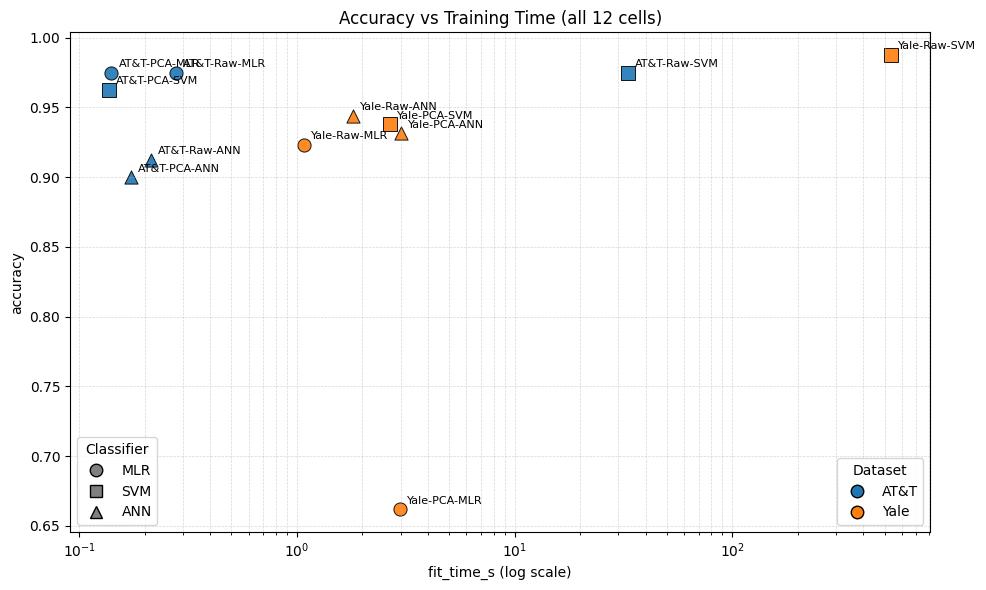

Accuracy/time trade-off: Pareto frontier cells are AT&T-PCA-SVM, AT&T-PCA-MLR, Yale-Raw-MLR, Yale-Raw-SVM. Using the harmonic mean of normalized accuracy and normalized log-speed, the best trade-off is AT&T-PCA-MLR (accuracy=0.9750, fit_time_s=0.167).


In [37]:
# §8.1 Accuracy vs Training Time scatter plot
marker_by_classifier = {"MLR": "o", "SVM": "s", "ANN": "^"}
color_by_dataset = {"AT&T": TAB10(0), "Yale": TAB10(1)}
plot_df = master_df.copy()
plot_df["fit_time_s"] = plot_df["fit_time_s"].astype(float)
plot_df["accuracy"] = plot_df["accuracy"].astype(float)
plot_df["cell_label"] = (
    plot_df["dataset"].astype(str)
    + "-"
    + plot_df["feature"].astype(str)
    + "-"
    + plot_df["classifier"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in plot_df.iterrows():
    ax.scatter(
        row["fit_time_s"],
        row["accuracy"],
        marker=marker_by_classifier[row["classifier"]],
        color=color_by_dataset[row["dataset"]],
        edgecolor="black",
        linewidth=0.7,
        s=90,
        alpha=0.9,
    )
    ax.annotate(
        row["cell_label"],
        (row["fit_time_s"], row["accuracy"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("fit_time_s (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs Training Time (all 12 cells)")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

classifier_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker,
        color="white",
        markerfacecolor="gray",
        markeredgecolor="black",
        linestyle="None",
        markersize=9,
        label=classifier,
    )
    for classifier, marker in marker_by_classifier.items()
]
dataset_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor=color,
        markeredgecolor="black",
        linestyle="None",
        markersize=9,
        label=dataset,
    )
    for dataset, color in color_by_dataset.items()
]
legend_1 = ax.legend(handles=classifier_handles, title="Classifier", loc="lower left")
ax.add_artist(legend_1)
ax.legend(handles=dataset_handles, title="Dataset", loc="lower right")
plt.tight_layout()
plt.show()

accuracies = plot_df["accuracy"].to_numpy(dtype=float)
log_times = np.log10(plot_df["fit_time_s"].to_numpy(dtype=float))
plot_df["pareto_efficient"] = [
    not any(
        (other.accuracy >= point.accuracy)
        and (other.fit_time_s <= point.fit_time_s)
        and ((other.accuracy > point.accuracy) or (other.fit_time_s < point.fit_time_s))
        for other in plot_df.itertuples(index=False)
    )
    for point in plot_df.itertuples(index=False)
]
pareto_df = plot_df[plot_df["pareto_efficient"]].copy()
accuracy_range = accuracies.max() - accuracies.min()
log_time_range = log_times.max() - log_times.min()
pareto_df["norm_accuracy"] = (
    (pareto_df["accuracy"] - accuracies.min()) / accuracy_range
    if accuracy_range > 0
    else 1.0
)
pareto_df["norm_speed"] = (
    (log_times.max() - np.log10(pareto_df["fit_time_s"])) / log_time_range
    if log_time_range > 0
    else 1.0
)
pareto_df["tradeoff_score"] = np.where(
    (pareto_df["norm_accuracy"] + pareto_df["norm_speed"]) > 0,
    2
    * pareto_df["norm_accuracy"]
    * pareto_df["norm_speed"]
    / (pareto_df["norm_accuracy"] + pareto_df["norm_speed"]),
    0.0,
)
best_tradeoff = pareto_df.sort_values(
    ["tradeoff_score", "accuracy", "fit_time_s"],
    ascending=[False, False, True],
).iloc[0]
pareto_labels = ", ".join(pareto_df.sort_values("fit_time_s")["cell_label"])
print(
    "Accuracy/time trade-off: "
    f"Pareto frontier cells are {pareto_labels}. "
    f"Using the harmonic mean of normalized accuracy and normalized log-speed, "
    f"the best trade-off is {best_tradeoff['cell_label']} "
    f"(accuracy={best_tradeoff['accuracy']:.4f}, "
    f"fit_time_s={best_tradeoff['fit_time_s']:.3f})."
)


#### §7.1 Accuracy-Time Scatter 結果解讀

Accuracy-time scatter plot 將 12 個實驗單元置於同一 trade-off 平面。Pareto frontier 包含 AT&T-PCA-SVM、AT&T-PCA-MLR、Yale-Raw-MLR 與 Yale-Raw-SVM：前兩者以極低 fit time 達到 AT&T 上的高 accuracy，Yale-Raw-MLR 在約 4.822 秒內達到 0.9793，Yale-Raw-SVM 則取得最高 accuracy 但訓練成本極高。以 normalized accuracy 與 normalized log-speed 的 harmonic mean 評分，最佳折衷為 AT&T-PCA-MLR（accuracy=0.9750，fit_time_s=0.167）。

此圖的診斷意義在於評估目標與模型選擇的對應關係。以 Yale 最高準確率為目標時，SVM Raw 最強；若需在 Yale 上避免 500 秒以上訓練成本，MLR Raw 是高準確率且成本明顯較低的替代方案；若以快速穩定基準為目標，MLR + PCA 組合仍具效率。


# §8 總結論

本實驗的結果表明，shallow classifiers 的分類表現主要受特徵空間與資料結構的匹配程度所制約，而非模型容量本身的上限。PCA 所壓縮的變異類型、最佳化預算的充足程度、成像條件對線性邊界的支撐程度，三者共同決定了各實驗單元的結果差異。

PCA 對分類準確率的效益取決於資料集特性、分類器形式與最佳化設定，而非單一方向。AT&T 的主要身份訊號集中於少數主成分，PCA 保留 MLR 所需的線性資訊並降低計算成本；Yale Face B 中，前幾個主成分大量吸收光照方向與陰影變化，因此需要較高維 PCA 表徵與穩定優化器才能維持身份分類表現。

三個分類器呈現明確的 trade-off。SVM 達到最高準確率上限，但 raw 高維特徵上的訓練成本極高；ANN 在 Yale 上以可控訓練時間達到接近 SVM PCA 的表現，對光照變異的韌性高於一般線性投影解讀；MLR 為可解釋性最高的線性基準，sklearn LBFGS 版本在 Yale Raw 與 PCA 上分別達 0.9793 與 0.9564，但手刻 `MyMLR` 的 0.7822 驗證結果仍揭示 full-batch GD 對迭代預算與正則化設定的敏感性。AT&T 與 Yale 之間的系統性差異亦表明，資料難度不由類別數或樣本數決定，成像條件與類內光照變異才是 shallow classifiers 能否建立穩定決策邊界的根本制約。

與 Work2 的 SVD reconstruction 連結進一步確認，pixel-level reconstruction quality 與 classification utility 並不等價：PCA reconstruction error 隨 $k$ 持續下降，但 $k$--accuracy curve 在較小的 $k$ 即進入平台期，顯示分類器所需的是具判別力的投影方向，而非完整還原像素細節。若引入 CNN 或 transfer learning，關鍵改進不在於模型深度本身，而在於從局部影像結構與大規模預訓練中學習更穩定的 identity representation，直接針對本實驗所揭示的 illumination sensitivity。
